# Cost-critic figures — sweep `0e8xqg18`

**Standalone.** Nothing is imported from `plots/`; every estimator and every line of drawing
code is in this notebook. Data is pulled from wandb once and cached, so re-runs are offline.

**Sweep** `liam-paull/calibration_rl/0e8xqg18` — CPO and TRPOPID ("PIDLag") on
`SafetyPointGoal1-v0`. Each eval checkpoint stores 102 probe states with K=10 Monte-Carlo
rollouts each, plus the critic's prediction at those states.

Each algorithm is drawn at its **own** best config: every cell of the sweep grid is scored
by `SELECT["criterion"]` and the winner taken per algorithm, so CPO and PIDLag need not
share hyper-parameters.

### Layout

1. **Config** — paths, sweep, and how each algorithm's design point is chosen
2. **Style** — `STYLE` and `TEXT`: every colour, size and string, in one place
3. **Utilities** — all helpers at once: fetching, config selection, loading, estimators,
   drawing primitives
4. **Load**
5. **One section per figure** — that figure's own code sits directly above the figure it draws

To restyle everything, edit `STYLE`/`TEXT` in section 2 and re-run. To draw a different
design point, edit `SELECT` in section 1. To change one figure, edit the cell that draws
it — each starts with its own small knobs dict.

## 1. Config

In [1]:
import csv
import pathlib
import pickle
from concurrent.futures import ThreadPoolExecutor, as_completed

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Repo-anchored, so the same cache is used wherever the kernel starts.
REPO = pathlib.Path.cwd().resolve()
while not (REPO / "omnisafe").is_dir() and not (REPO / "plots").is_dir():
    if REPO.parent == REPO:
        raise RuntimeError("could not find the MICE repo root")
    REPO = REPO.parent


SWEEP = "liam-paull/calibration_rl/hyfcu0dx"
ENTITY_PROJECT, SWEEP_ID = SWEEP.rsplit("/", 1)
DATA_DIR = REPO / "figs" / f"sweep_{SWEEP_ID}"
FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

ALGOS = [("CPO", "CPO"), ("TRPOPID", "PIDLag")]          # (wandb id, display name)
TREES = {"CPO": DATA_DIR / f"eval_data_{SWEEP_ID}_cpo",
         "TRPOPID": DATA_DIR / f"eval_data_{SWEEP_ID}_pidlag"}
CFG_KEYS = ["algo", "adv", "update_iters", "critic_lr"]   # the sweep grid

# Which design point each algorithm is drawn at.  Rather than pinning one cell for both,
# every config is scored by SELECT["criterion"] and the winner taken per algorithm
# (section 3.2), so CPO and PIDLag may well land on different hyper-parameters.
SELECT = {
    "criterion": "ratio",     # "ratio" | "EpRet" | "TotalCost" -- see CRITERIA in 3.2
    "variant": "any",         # restrict candidates to one adv-estimation-method, or "any"
    "override": {},           # pin an algo by name: {"CPO": "plain_iters10_lr0.0003"}
}

SPE = 20_000            # env steps per epoch
GAMMA = 0.99            # cost_gamma
COST_LIMIT = 10.0
K_ROLLOUTS = 10         # rollouts per probe state

RAW_CSV = DATA_DIR / "raw_runs.csv"
TS_CSV = DATA_DIR / "all_runs_timeseries.csv"
HISTORY_KEYS = ["TotalEnvSteps", "Metrics/EpRet", "Metrics/EpCost",
                "PooledMC/Correlation_r", "PooledMC/Correlation_c"]

print("repo   :", REPO)
print("cache  :", DATA_DIR)
print("figures:", FIG_DIR)

repo   : /home/kaustubh/projects/calibration_rl/MICE
cache  : /home/kaustubh/projects/calibration_rl/MICE/figs/sweep_hyfcu0dx
figures: /home/kaustubh/projects/calibration_rl/MICE/figs/sweep_hyfcu0dx/figures


## 2. Style

`STYLE` is the palette, type, marks and panel geometry; `TEXT` is every string a figure
shows. Nothing below hard-codes either, so editing these two dicts restyles every figure.

Geometry is **inches per panel** rather than a whole-figure size, so panels keep the same
physical size whatever the panel count and figures line up beside each other. The palette
and chrome match `cpo_vs_pidlag.ipynb`.

In [2]:
STYLE = {
    "algo": {"CPO": "#0072B2", "PIDLag": "#D55E00"},     # Okabe-Ito blue / vermillion
    "groups": ["#bdbdbd", "#9e9ac8", "#c44e52"],         # ordered low -> high value
    "heads": {"r": "#0072B2", "c": "#D55E00"},           # reward / cost (budget figure)
    # advantage estimator, for the CPO-only comparison: "plain" keeps the blue it has
    # everywhere else in the notebook, since that is the config every other figure shows
    "variant": {"plain": "#0072B2", "gae": "#009E73"},
    "ink": {"title": "#1a1a1a", "label": "#5a5a5a", "spine": "#909090",
            "tick": "#8a8a8a", "grid": "#d8d8d8", "rule": "#5a5a5a"},

    "font": {"family": "DejaVu Sans", "title": 28, "label": 21, "tick": 17,
             "series": 23, "note": 16, "legend": 22, "suptitle": 30},

    "line": {"width": 2.2, "marker": 5, "band_alpha":  0.18,
             "grid": 1.0, "spine": 1.0, "tick_len": 3.6, "tick_width": 1.0,
             "rule_width": 1.7, "rule_dash": (0, (5, 3)),
             "ceiling_width": 1.8, "ceiling_dash": (0, (1, 2)),
             "scatter_size": 46, "scatter_alpha": 0.75},

    # inches
    "panel": {"w": 4.80, "h": 4.08, "wgap": 1.30, "hgap": 1.45,
              "left": 1.15, "right": 0.12, "top": 0.62, "bottom": 1.00},

    "band": "sem",                      # "sem" or "sd"
    "dpi": 300, "pad_inches": 0.1,
    "xticks": [3e4, 1e5, 3e5, 1e6, 3e6, 1e7],
}

TEXT = {
    "xlabel_steps": "Total env steps",
    "cost_limit": "cost limit",
    "limit_rule": "cost reaches limit",
    "fig1_titles": ["Episode Return", "Episode Cost",
                    "Correlation (reward)", "Correlation (cost)"],
    "fig2_titles": ["Critic vs reference", "Signed error, all probes",
                    "Signed error by value group", "Critic as a classifier"],
    "fig2_suptitle": "{algo} — cost critic on its own probe states",
    "scatter_x": r"Reference $\tilde V_c$ (10 rollouts)",
    "scatter_y": r"Cost critic $\hat V_c$",
    "error_y": r"$\hat V_c - \tilde V_c$",
    "error_pct_y": r"$(\hat V_c - \tilde V_c)\,/\,\tilde V_c$   (%)",
    "fig2_pct_title": "Relative error by value group",
    "auroc_y": "AUROC (high value)",
    "identity": "perfect prediction",
    "critic": "critic",
    "ceiling": "split-half ceiling",
    "groups": ["low value", "intermediate value", "high value"],
    "group_defs": [r"low: $\tilde V_c < \gamma^{500}$",
                   r"intermediate: $\gamma^{500} \leq \tilde V_c < \gamma^{5}$",
                   r"high: $\tilde V_c \geq \gamma^{5}$"],
    "threshold_title": "Threshold sensitivity",
    "threshold_variants_title": "Threshold sensitivity — {algo}",
    "threshold_x": r"threshold $v$:   high value $= \tilde V_c \geq v$",
    "threshold_y": "AUROC (median, IQR)",
    "threshold_before": "before limit", "threshold_after": "after limit",
    "groups_title": "Value groups of the probe states",
    "groups_y": "Share of probe states",
    "rel_titles": ["Correlation (reward)", "Correlation (cost)",
                   "Split-half (reward)", "Split-half (cost)"],
    "rel_observed": "critic vs reference",
    "rel_anova": r"ANOVA ceiling $\rho_{\max}$",
    "rel_split": r"split-half estimate of $\rho_{\max}$",
    "budget_titles": ["Error vs K", "Reliability vs K",
                      "Split-half across training", "Split-half vs K"],
    "budget_x_k": "rollouts per probe state K",
    "budget_x_half": "rollouts per half K",
    "budget_y_err": "RMS error / spread across states",
    "budget_y_rho": r"$\rho_{\max}(K)$",
    "budget_y_split": "Corr(two disjoint estimates)",
    "budget_extrap": "extrapolated\n(no data)",
    "budget_pred": r"ANOVA prediction $\rho_{\max}(K)^2$",
    "reward": "reward", "cost": "cost",
}

# appended to the scatter axis labels so the reader knows which scale is in use
SCALE_NOTE = {"linear": "", "symlog": ", symlog", "log": ", log"}


def apply_style():
    """Push STYLE into rcParams. Re-run after editing STYLE."""
    f, l, ink = STYLE["font"], STYLE["line"], STYLE["ink"]
    mpl.rcParams.update({
        "figure.dpi": 110, "savefig.dpi": STYLE["dpi"],
        "font.family": "sans-serif", "font.sans-serif": [f["family"]], "font.size": f["tick"],
        "axes.titlesize": f["title"], "axes.titlecolor": ink["title"], "axes.titlepad": 8,
        "axes.labelsize": f["label"], "axes.labelcolor": ink["label"],
        "axes.edgecolor": ink["spine"], "axes.linewidth": l["spine"],
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True,
        "grid.color": ink["grid"], "grid.linewidth": l["grid"], "grid.alpha": 1.0,
        "xtick.labelsize": f["tick"], "ytick.labelsize": f["tick"],
        "xtick.color": ink["tick"], "ytick.color": ink["tick"],
        "xtick.labelcolor": ink["label"], "ytick.labelcolor": ink["label"],
        "xtick.direction": "out", "ytick.direction": "out",
        "xtick.major.size": l["tick_len"], "ytick.major.size": l["tick_len"],
        "xtick.major.width": l["tick_width"], "ytick.major.width": l["tick_width"],
        "xtick.minor.visible": False, "ytick.minor.visible": False,
        "legend.fontsize": f["legend"], "legend.frameon": False,
    })


apply_style()
ALGO_COLOR = {disp: STYLE["algo"][disp] for _, disp in ALGOS}
T_LOW, T_HIGH = GAMMA ** 500, GAMMA ** 5          # value-group thresholds
print("style applied |", ALGO_COLOR)

style applied | {'CPO': '#0072B2', 'PIDLag': '#D55E00'}


## 3. Utilities

Everything reusable, in one place: **3.1** fetching and caching, **3.2** config selection,
**3.3** the estimators, **3.4** drawing primitives. Nothing here draws a specific figure —
that code lives beside each figure below.

### 3.1 Fetching and caching

In [3]:
def save_csv(df, path):
    """Write via temp + rename, so an interrupted run leaves no half-written cache."""
    tmp = str(path) + ".tmp"
    df.to_csv(tmp, index=False)
    pathlib.Path(tmp).replace(path)


def to_numeric(df, cols):
    """Force numeric dtype.

    wandb's history() returns a sparsely-logged column (the PooledMC correlations, present
    only at eval epochs) as dtype=object, while the same data via CSV comes back float64.
    Aggregating the object form concatenates the NaNs instead of averaging them.
    """
    for c in cols:
        if c in df:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def cell_of(row):
    """Design-point name: '<adv>_iters<update_iters>_lr<critic_lr>'."""
    return f"{row.adv}_iters{int(row.update_iters)}_lr{row.critic_lr:g}"


def fetch_summary():
    import wandb
    api = wandb.Api(timeout=120)
    rows = []
    for r in api.sweep(SWEEP).runs:
        c = r.config
        rows.append(dict(run_id=r.id, name=r.name, state=r.state, algo=c.get("algo"),
                         adv=c.get("adv-estimation-method"),
                         update_iters=c.get("algo-cfgs.update-iters"),
                         critic_lr=c.get("model-cfgs.critic.lr"),
                         cost_limit=c.get("cost-limit"), seed=c.get("seed"),
                         EpRet=r.summary.get("Metrics/EpRet"),
                         TotalCost=r.summary.get("Metrics/TotalCost")))
    return pd.DataFrame(rows)


def fetch_timeseries(raw):
    import wandb
    api = wandb.Api(timeout=180)
    out = []
    for i, r in raw.iterrows():
        h = api.run(f"{ENTITY_PROJECT}/{r.run_id}").history(keys=HISTORY_KEYS, samples=100_000)
        for c in ["algo", "adv", "update_iters", "critic_lr", "seed", "run_id"]:
            h[c] = r[c]
        out.append(h)
        print(f"  {i + 1}/{len(raw)} {r.run_id}", end="\r", flush=True)
    return pd.concat(out, ignore_index=True)


def tree_status(algo, cell, raw):
    """Is the local probe tree complete? Checked per seed, not just 'directory exists'.

    A partial tree is the dangerous case: a truncated seed would silently shorten every
    curve rather than raise.
    """
    root = TREES[algo]
    counts = {}
    for seed in sorted(raw[(raw.algo == algo) & (raw.cell == cell)].seed):
        d = root / cell / f"seed{seed}"
        counts[seed] = len(list(d.glob("epoch_*.pkl"))) if d.is_dir() else 0
    if not counts:
        return False, "no runs matched"
    if min(counts.values()) == 0:
        return False, f"seeds absent: {[s for s, n in counts.items() if n == 0]}"
    if len(set(counts.values())) > 1:
        return False, f"uneven checkpoint counts: {sorted(set(counts.values()))}"
    return True, f"{len(counts)} seeds x {next(iter(counts.values()))} checkpoints"


def download_tree(algo, cell, raw, workers=5):
    """Download this cell's eval_data pickles, skipping files already on disk."""
    import wandb
    root = TREES[algo]
    sel = raw[(raw.algo == algo) & (raw.cell == cell)]

    def one(run_id, dest):
        api = wandb.Api(timeout=180)               # one Api per thread
        dest.mkdir(parents=True, exist_ok=True)
        got = 0
        for art in api.run(f"{ENTITY_PROJECT}/{run_id}").logged_artifacts():
            if art.type != "eval_data":
                continue
            for f in art.files():
                if f.name.lower().endswith(".pkl") and not (dest / f.name).exists():
                    f.download(root=str(dest), replace=False)
                    got += 1
        return run_id, got

    jobs = {r.run_id: root / cell / f"seed{r.seed}" for _, r in sel.iterrows()}
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = {ex.submit(one, rid, d): rid for rid, d in jobs.items()}
        for i, fut in enumerate(as_completed(futs), 1):
            rid, got = fut.result()
            print(f"  [{i}/{len(jobs)}] {rid}: +{got} new", flush=True)

### 3.2 Config selection

Every cell of the sweep grid is scored by aggregating its seeds, and the best-scoring cell is
taken **per algorithm** — so CPO and PIDLag are each shown at their own best hyper-parameters
rather than at one shared design point.

| criterion | score per config | best |
|---|---|---|
| `ratio` *(default)* | per-seed `EpRet / TotalCost`, averaged over seeds | max |
| `EpRet` | mean final `Metrics/EpRet` | max |
| `TotalCost` | mean `Metrics/TotalCost` over the whole run | min |

`SELECT["variant"]` restricts the candidate pool to one `adv-estimation-method` (`"any"`
searches all). `SELECT["override"]` pins an algorithm to a named cell, bypassing the score —
`{"CPO": "plain_iters10_lr0.0003"}` reproduces the design point this notebook used before.

The scoring matches `fig1.ipynb`, so both notebooks pick the same config for the same
criterion.

In [4]:
CRITERIA = {
    "ratio":     dict(label="EpRet / TotalCost", mode="max"),
    "EpRet":     dict(label="EpRet",             mode="max"),
    "TotalCost": dict(label="TotalCost",         mode="min"),
}


def score_configs(raw, variant="any"):
    """Score every config in the sweep by aggregating its seeds.

    `variant` restricts the candidate pool to one adv-estimation-method; "any" searches all.
    """
    cand = raw if variant == "any" else raw[raw.adv == variant]
    if cand.empty:
        raise ValueError(f"no runs with adv={variant!r}; have {sorted(raw.adv.unique())}")
    cand = cand.assign(ratio=cand.EpRet / cand.TotalCost)
    return (cand.groupby(CFG_KEYS)
            .agg(ratio=("ratio", "mean"), EpRet=("EpRet", "mean"),
                 TotalCost=("TotalCost", "mean"), n_seeds=("seed", "size"))
            .reset_index())


def best_cells(raw, criterion, variant="any", override=None):
    """Design point per algorithm: ({algo: cell}, the winning scored rows indexed by algo).

    The pick is made independently within each algorithm, so the two need not agree.  An
    overridden algo still keeps its scored row in the returned table: that row is what the
    criterion would have chosen, which is worth seeing beside the pin.
    """
    if criterion not in CRITERIA:
        raise ValueError(f"unknown criterion {criterion!r}; pick one of {list(CRITERIA)}")
    g = score_configs(raw, variant)
    pick = g.groupby("algo")[criterion]
    idx = pick.idxmax() if CRITERIA[criterion]["mode"] == "max" else pick.idxmin()
    best = g.loc[idx].set_index("algo")
    cells = {algo: cell_of(best.loc[algo]) for algo in best.index}
    for algo, cell in (override or {}).items():
        if algo not in cells:
            raise ValueError(f"override names {algo!r}, not in the sweep: {list(cells)}")
        if cell not in set(raw.loc[raw.algo == algo, "cell"]):
            raise ValueError(f"override {algo}={cell!r} is not a cell of this sweep")
        cells[algo] = cell
    return cells, best

### 3.3 Loading probes and the estimators

In [5]:
def load_seed(seed_dir, block="pooled"):
    """One seed's checkpoints: critic predictions and the K Monte-Carlo rollouts per probe."""
    out = []
    for path in sorted(seed_dir.glob("epoch_*.pkl")):
        with open(path, "rb") as fh:
            d = pickle.load(fh)
        raw = d[block]["raw"]
        out.append({"epoch": int(d["epoch"]),
                    "pred": {h: np.asarray(raw[h]["pred"], float) for h in ("r", "c")},
                    "G": {h: np.asarray(raw[h]["returns"], float) for h in ("r", "c")}})
    return sorted(out, key=lambda p: p["epoch"])


def load_algo(algo, cell, ts):
    """Stack one algorithm's probe data and training curves.

    Returns arrays shaped (n_seeds, n_checkpoints, n_probes[, K]), so everything downstream
    is plain numpy over a seed axis.
    """
    seeds = sorted(int(p.name[4:]) for p in (TREES[algo] / cell).glob("seed*"))
    per = [load_seed(TREES[algo] / cell / f"seed{s}") for s in seeds]
    n_ck = min(len(p) for p in per)
    per = [p[:n_ck] for p in per]

    d = {"algo": algo, "cell": cell, "seeds": seeds,
         "steps": np.array([(p["epoch"] + 1) * SPE for p in per[0]], float),
         "epochs": np.array([p["epoch"] for p in per[0]], int)}
    for head in ("r", "c"):
        d[f"pred_{head}"] = np.stack([[ck["pred"][head] for ck in s] for s in per])
        d[f"G_{head}"] = np.stack([[ck["G"][head] for ck in s] for s in per])

    h = ts[(ts.algo == algo) & (ts.cell == cell)]
    grids = [g.sort_values("TotalEnvSteps") for _, g in h.groupby("seed")]
    n = min(len(g) for g in grids)
    d["hist_steps"] = grids[0]["TotalEnvSteps"].to_numpy()[:n]
    d["EpRet"] = np.stack([g["Metrics/EpRet"].to_numpy()[:n] for g in grids])
    d["EpCost"] = np.stack([g["Metrics/EpCost"].to_numpy()[:n] for g in grids])

    # where the seed-mean episodic cost first reaches the limit: everything to the left is
    # the constraint-reduction phase the critic diagnostics are about
    mean_cost = d["EpCost"].mean(0)
    below = np.where(mean_cost <= COST_LIMIT)[0]
    d["x0"] = float(d["hist_steps"][below[0]]) if len(below) else float(d["hist_steps"][-1])
    return d


# ---- estimators ----------------------------------------------------------------------

def rho_obs(pred, G):
    """Observed Corr(V_hat, Gbar), Gbar = mean of the K rollouts."""
    gbar = G.mean(-1)
    if pred.std() == 0 or gbar.std() == 0:
        return np.nan
    return float(np.corrcoef(pred, gbar)[0, 1])


def rho_max(G):
    """Ceiling on Corr(V_hat, Gbar) for a perfect critic.

    Gbar is a noisy estimate of V, so Corr(V_hat, Gbar) = Corr(V_hat, V) * rho_max with
    rho_max = sqrt(Var[V] / Var[Gbar]) and Var[V] = Var[Gbar] - sigma^2 / K, estimated by
    one-way ANOVA over the probes (ddof=1 on both variances).
    """
    n, K = G.shape
    if n < 2 or K < 2:
        return np.nan
    sigma2 = G.var(axis=1, ddof=1).mean()          # pooled within-state
    between = G.mean(axis=1).var(ddof=1)           # between-state
    if between <= 0:
        return 0.0
    return float(np.sqrt(max(between - sigma2 / K, 0.0) / between))


def splithalf_r(G, n_rep=200, seed=0):
    """Corr between two disjoint half-means, averaged over random splits.

    Assumes only that rollouts are independent, so it cross-checks rho_max without the
    ANOVA variance model: Corr(Gbar_A, Gbar_B) = rho_max(K/2)^2.
    """
    n, K = G.shape
    k = K // 2
    if n < 3 or k < 1:
        return np.nan
    rng = np.random.default_rng(seed)
    order = np.argsort(rng.random((n_rep, n, K)), axis=2)
    Gp = np.take_along_axis(np.broadcast_to(G, (n_rep, n, K)), order, axis=2)
    A, B = Gp[:, :, :k].mean(2), Gp[:, :, k:2 * k].mean(2)
    Ac, Bc = A - A.mean(1, keepdims=True), B - B.mean(1, keepdims=True)
    den = np.sqrt((Ac ** 2).sum(1) * (Bc ** 2).sum(1))
    ok = den > 0
    return float(np.mean((Ac * Bc).sum(1)[ok] / den[ok])) if ok.any() else np.nan


def rho_max_from_split(r):
    """Spearman-Brown: rho_max(K) from the half-vs-half correlation of equal halves."""
    return float(np.sqrt(2 * r / (1 + r))) if r > 0 else 0.0


def avg_ranks(x):
    _, inv, counts = np.unique(x, return_inverse=True, return_counts=True)
    return (np.cumsum(counts) - (counts - 1) / 2.0)[inv]


def auroc(score, label):
    """Mann-Whitney AUROC: P(a labelled state outranks an unlabelled one)."""
    n1 = int(label.sum())
    n0 = len(label) - n1
    if n1 == 0 or n0 == 0:
        return np.nan
    return float((avg_ranks(score)[label].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def value_groups(v):
    """Masks for low / intermediate / high value, split on the reference."""
    return [v < T_LOW, (v >= T_LOW) & (v < T_HIGH), v >= T_HIGH]


def map_checkpoints(d, head, fn):
    """Apply fn(pred, G) over every (seed, checkpoint); returns (n_seeds, n_checkpoints)."""
    pred, G = d[f"pred_{head}"], d[f"G_{head}"]
    return np.array([[fn(pred[s, t], G[s, t]) for t in range(pred.shape[1])]
                     for s in range(pred.shape[0])], float)

### 3.4 Drawing primitives

In [6]:
def make_axes(ncols, nrows=1, legend_in=0.0, left_extra=0.0, panel_w=None, panel_h=None,
              title_in=0.0):
    """Figure laid out from STYLE['panel'], in inches.

    legend_in reserves that many inches of blank space at the bottom for a common legend,
    so a legend can never land on the x labels; title_in does the same at the top, for a
    figure-wide title that would otherwise share a band with the panel titles.
    """
    P = STYLE["panel"]
    w, h = panel_w or P["w"], panel_h or P["h"]
    left, bottom = P["left"] + left_extra, P["bottom"] + legend_in
    top = P["top"] + title_in
    fig_w = left + ncols * w + (ncols - 1) * P["wgap"] + P["right"]
    fig_h = top + nrows * h + (nrows - 1) * P["hgap"] + bottom
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), squeeze=False)
    fig.subplots_adjust(left=left / fig_w, right=1 - P["right"] / fig_w,
                        top=1 - top / fig_h, bottom=bottom / fig_h,
                        wspace=P["wgap"] / w, hspace=P["hgap"] / h)
    return fig, (axes[0] if nrows == 1 else axes)


def fmt_steps(v, _=None):
    return f"{v/1e6:g}M" if v >= 1e6 else f"{v/1e3:g}k"


def log_steps(ax, x_first, x_last, xlabel=True, right_pad=1.0):
    """Shared log-steps x axis: fixed ticks labelled 30k ... 10M, no left margin."""
    ax.set_xscale("log")
    ax.set_xticks(STYLE["xticks"])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_steps))
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.set_xlim(x_first, x_last * right_pad)       # after set_xticks, which widens the view
    if xlabel:
        ax.set_xlabel(TEXT["xlabel_steps"])


def spread(M, how=None):
    """Seed mean and band half-width: standard error (default) or standard deviation."""
    M = np.asarray(M, float)
    m = np.nanmean(M, 0)
    sd = np.nanstd(M, 0, ddof=1) if M.shape[0] > 1 else np.zeros(M.shape[1])
    if (how or STYLE["band"]) == "sem":
        return m, sd / np.sqrt(np.maximum(np.sum(np.isfinite(M), 0), 1))
    return m, sd


def band(ax, x, M, color, lw=None, ls="-", marker=None, label=None, zorder=3):
    """Seed-mean line with its band."""
    L = STYLE["line"]
    m, e = spread(M)
    ax.plot(x, m, color=color, lw=lw or L["width"], ls=ls, label=label, zorder=zorder,
            marker=marker, markersize=L["marker"], markeredgewidth=0)
    ax.fill_between(x, m - e, m + e, color=color, alpha=L["band_alpha"], lw=0,
                    zorder=zorder - 1)
    return m


def rule_h(ax, y, text=None, where=3e6):
    """Horizontal reference rule (e.g. the cost limit), optionally annotated."""
    L, ink = STYLE["line"], STYLE["ink"]
    ax.axhline(y, color=ink["rule"], lw=L["rule_width"], ls=L["rule_dash"], zorder=4)
    if text:
        lo, hi = ax.get_ylim()
        ax.text(where, y + 0.19 * (hi - lo), text, fontsize=STYLE["font"]["note"],
                style="italic", color=ink["label"], ha="center", va="center")


def rule_v(ax, x):
    """Vertical reference rule (e.g. where episodic cost reaches the limit)."""
    ax.axvline(x, color=STYLE["ink"]["rule"], lw=1.3, ls=(0, (6, 3, 1, 3)), zorder=1)


def series_labels(fig, ax, ends, x_end, pad=1.35, right_pad_px=8):
    """Label curves at their right end, in place of a legend.

    Labels go beyond the last sample, where nothing is drawn, and the axis is then widened
    until the widest fits -- so a label can never sit on the data.
    """
    lo, hi = ax.get_ylim()
    span = hi - lo
    ends = sorted(ends)
    gap = 0.11 * span
    if len(ends) == 2 and ends[1][0] - ends[0][0] < gap:
        mid = 0.5 * (ends[0][0] + ends[1][0])
        ends = [(mid - gap / 2,) + ends[0][1:], (mid + gap / 2,) + ends[1][1:]]
    ends = [(min(max(y, lo + 0.05 * span), hi - 0.05 * span), t, c) for y, t, c in ends]

    ax.set_xlim(right=x_end * pad * 1.05)
    texts = [ax.text(x_end * pad, y, t, color=c, fontsize=STYLE["font"]["series"],
                     fontweight="bold", ha="left", va="center") for y, t, c in ends]
    for _ in range(8):
        fig.canvas.draw()
        box = ax.get_window_extent()
        over = max(t.get_window_extent().x1 for t in texts) - (box.x1 - right_pad_px)
        if over <= 0:
            break
        x0, x1 = ax.get_xlim()
        ax.set_xlim(right=x1 * 10 ** (over * np.log10(x1 / x0) / box.width * 1.10))


def _reading_order(entries, ncol):
    """Reorder entries so a wrapped legend reads left-to-right, top-to-bottom.

    Matplotlib fills a multi-column legend column by column, so wrapping three ordered
    keys into two columns would show "low, high / intermediate".
    """
    n = len(entries)
    nrow = -(-n // ncol)
    return [entries[r * ncol + c] for c in range(ncol) for r in range(nrow)
            if r * ncol + c < n]


def legend_below(fig, entries, ncol=4, y=0.012):
    """One legend in the space reserved by make_axes(legend_in=...).

    A legend wider than the figure is never clipped -- savefig(bbox_inches="tight") grows
    the canvas to fit it, padding the panels with blank margin instead, which is how an
    over-wide legend quietly shrinks the plot.  So measure it and wrap to fewer columns
    until it fits the axes band; if the extra rows then reach the x labels, drop it.
    """
    sp = fig.subplotpars
    band = sp.right - sp.left
    inv = fig.transFigure.inverted()
    leg = None
    for n in range(max(1, min(ncol, len(entries))), 0, -1):
        if leg is not None:
            leg.remove()
        ordered = _reading_order(entries, n)
        leg = fig.legend([h for h, _ in ordered], [l for _, l in ordered],
                         loc="lower center", ncol=n, frameon=False,
                         fontsize=STYLE["font"]["legend"], bbox_to_anchor=(0.5, y))
        fig.canvas.draw()
        box = leg.get_window_extent().transformed(inv)
        if box.width <= band:
            break
    # Clear the axes' *tight* box, not the axes box: what a legend actually runs into
    # is the x tick labels and the x label hanging below it.
    floor = min(a.get_tightbbox().transformed(inv).y0 for a in fig.get_axes())
    over = box.y1 - (floor - 0.015)
    if over > 0:
        leg.set_bbox_to_anchor((0.5, y - over), transform=fig.transFigure)
    return leg


def suptitle(fig, text):
    """Figure title, placed clear of the panel titles.

    fig.suptitle's own default sits in the same band the axes titles occupy, so at this
    type size the two collide; offset by the height rcParams already gives a panel title.
    Pair it with make_axes(title_in=...), which reserves the room.
    """
    f = STYLE["font"]
    head_in = (f["title"] * 1.4 + mpl.rcParams["axes.titlepad"]) / 72.0
    y = fig.subplotpars.top + (head_in + 0.10) / fig.get_figheight()
    return fig.suptitle(text, fontsize=f["suptitle"], color=STYLE["ink"]["title"],
                        y=y, va="bottom")


def thin_tick_labels(fig, ax, axis="x", min_gap_px=8):
    """Hide tick labels that would collide with the previous one, keeping every mark.

    A hand-picked tick list cannot know how wide a label renders: on the threshold
    figure's log axis $\\gamma^0$ and $\\gamma^5$ are 5% apart, so their labels overlap
    however few ticks are chosen.
    """
    fig.canvas.draw()
    labels = ax.get_xticklabels() if axis == "x" else ax.get_yticklabels()
    span = (lambda b: (b.x0, b.x1)) if axis == "x" else (lambda b: (b.y0, b.y1))
    shown = sorted((t for t in labels if t.get_text()),
                   key=lambda t: span(t.get_window_extent())[0])
    edge = None
    for t in shown:
        lo, hi = span(t.get_window_extent())
        if edge is not None and lo < edge + min_gap_px:
            t.set_visible(False)
        else:
            edge = hi


def line_key(color, lw=None, ls="-", marker=None):
    L = STYLE["line"]
    return Line2D([], [], color=color, lw=lw or L["width"], ls=ls, marker=marker,
                  markersize=L["marker"], markeredgewidth=0)


def dot_key(color):
    return Line2D([], [], color=color, marker="o", ls="none",
                  markersize=STYLE["line"]["marker"] + 3, markeredgewidth=0)


def save(fig, stem, formats=("png", "pdf")):
    for ext in formats:
        fig.savefig(FIG_DIR / f"{stem}.{ext}", dpi=STYLE["dpi"], bbox_inches="tight",
                    pad_inches=STYLE["pad_inches"], facecolor="white")
    print("saved:", stem, "/".join(formats))


def show(*stems, width=1250):
    try:
        from IPython.display import Image, display
    except ImportError:
        return
    for s in stems:
        display(Image(filename=str(FIG_DIR / f"{s}.png"), width=width))

## 4. Load

Fetches on a cold start, otherwise reads the caches. Each algorithm's design point is
picked by `SELECT` (section 1) and reported below, then its probe tree is verified per
seed and re-downloaded if a previous run was interrupted.

Changing `SELECT["criterion"]` can move an algorithm onto a cell whose probe pickles are
not on disk yet, so the first run after such a change may download a fresh tree.

In [7]:
raw = pd.read_csv(RAW_CSV) if RAW_CSV.exists() else fetch_summary()
save_csv(raw, RAW_CSV)
raw = to_numeric(raw, ["EpRet", "TotalCost", "seed", "update_iters", "critic_lr"])
raw["cell"] = raw.apply(cell_of, axis=1)

ts = pd.read_csv(TS_CSV) if TS_CSV.exists() else fetch_timeseries(raw)
save_csv(ts, TS_CSV)
ts = to_numeric(ts, HISTORY_KEYS)
ts["cell"] = ts.apply(cell_of, axis=1)

CELLS, BEST = best_cells(raw, SELECT["criterion"], SELECT["variant"], SELECT["override"])
_crit = CRITERIA[SELECT["criterion"]]
print(f"design point: best by {_crit['label']} ({_crit['mode']}), "
      f"variant={SELECT['variant']!r}")
for algo, disp in ALGOS:
    b = BEST.loc[algo]
    print(f"  {disp:>7}: {CELLS[algo]}"
          + (f"  (pinned; {_crit['label']} would pick {cell_of(b)})"
             if CELLS[algo] != cell_of(b) else
             f"  -- EpRet {b.EpRet:.2f}, TotalCost {b.TotalCost:,.0f}, "
             f"ratio {b.ratio:.3g}, {int(b.n_seeds)} seeds"))

for algo, disp in ALGOS:
    ok, detail = tree_status(algo, CELLS[algo], raw)
    if not ok:
        print(f"{disp}: incomplete -- {detail}; downloading {CELLS[algo]}")
        download_tree(algo, CELLS[algo], raw)
        ok, detail = tree_status(algo, CELLS[algo], raw)
        if not ok:
            raise RuntimeError(f"{disp}: still incomplete -- {detail}")
    print(f"{disp}: {detail}")

DATA = {algo: load_algo(algo, CELLS[algo], ts) for algo, _ in ALGOS}
X_FIRST = min(d["hist_steps"][0] for d in DATA.values())
X_LAST = max(d["hist_steps"][-1] for d in DATA.values())

for algo, disp in ALGOS:
    d = DATA[algo]
    print(f"{disp:>7}: {d['cell']} | {len(d['seeds'])} seeds, "
          f"{len(d['steps'])} checkpoints, {d['G_c'].shape[2]} probes "
          f"x K={d['G_c'].shape[3]}, cost reaches limit at {d['x0']/1e6:.2f}M steps")

design point: best by EpRet / TotalCost (max), variant='any'
      CPO: plain_iters2_lr0.0003  -- EpRet 17.42, TotalCost 139,818, ratio 0.000125, 5 seeds
   PIDLag: gae_iters2_lr0.0001  -- EpRet 15.44, TotalCost 108,770, ratio 0.000142, 5 seeds
CPO: 5 seeds x 37 checkpoints
PIDLag: 5 seeds x 37 checkpoints
    CPO: plain_iters2_lr0.0003 | 5 seeds, 37 checkpoints, 102 probes x K=10, cost reaches limit at 5.52M steps
 PIDLag: gae_iters2_lr0.0001 | 5 seeds, 37 checkpoints, 102 probes x K=10, cost reaches limit at 0.34M steps


## 5. Figure 1 — training curves and critic correlation

Episode return, episode cost against the limit, and how well each critic correlates with the
K-rollout reference $\bar G$ for the reward and cost heads. Algorithms are labelled at the
end of their curves instead of with a legend.

saved: fig1 png/pdf


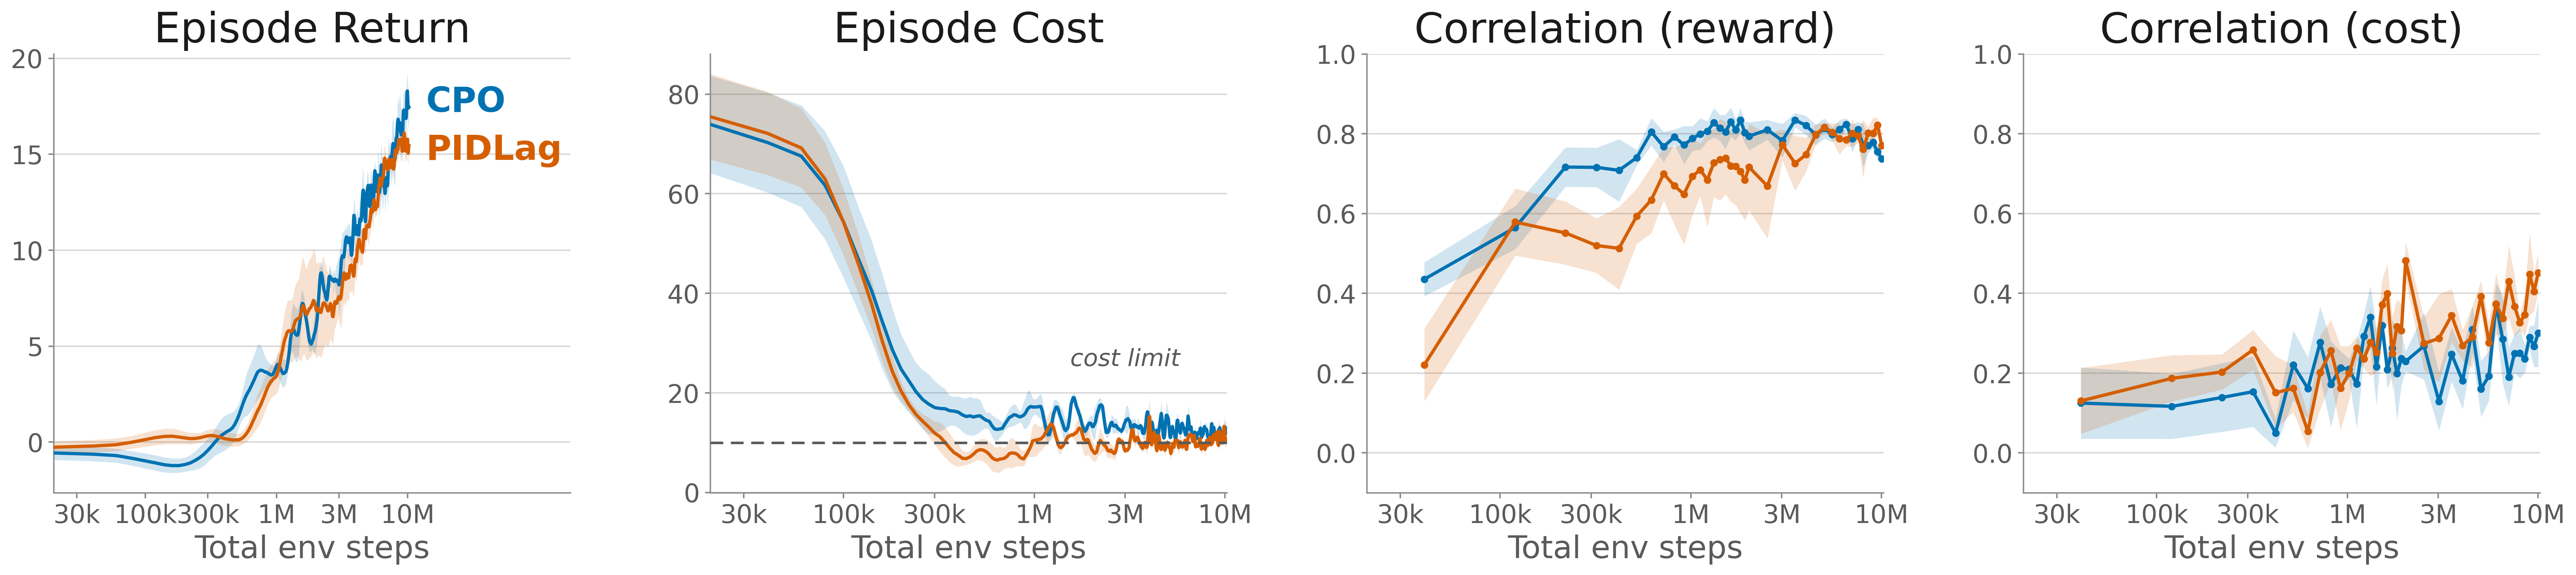

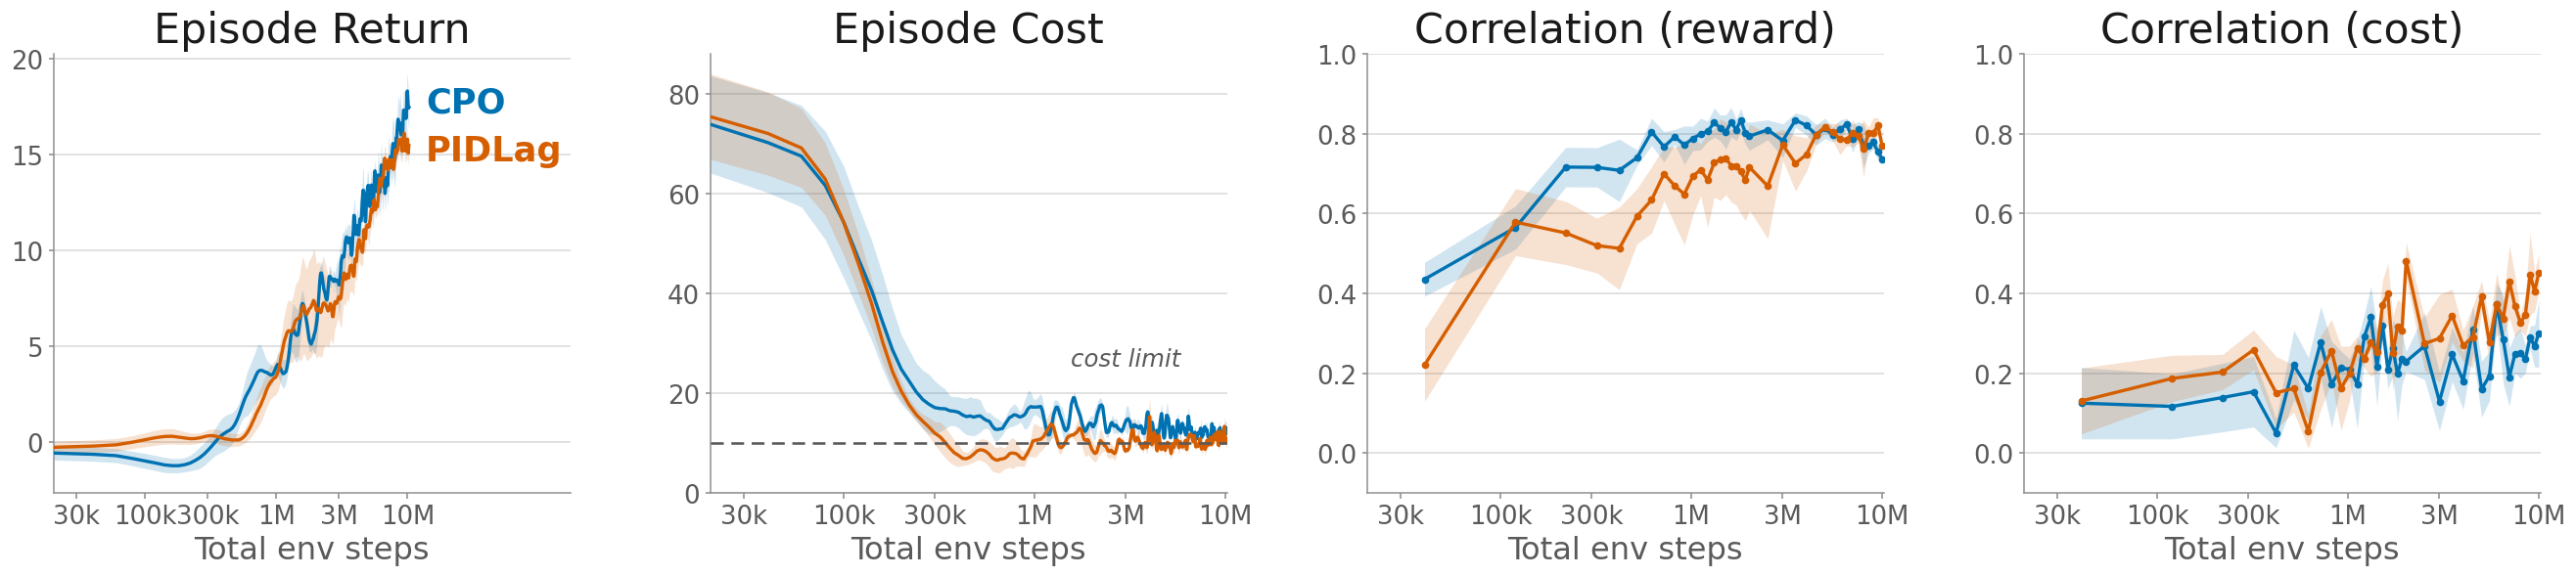

In [8]:
FIG1 = {
    "corr_ylim": (-0.10, 1.0),      # correlation panels
    "smooth": 5,                    # running mean (epochs) on the return/cost curves
    "limit_note_x": 3e6,            # where "cost limit" sits
}


def smooth(M, w):
    """Running mean along the last axis, edge-normalised."""
    if w <= 1:
        return M
    k = np.ones(w)
    num = np.apply_along_axis(lambda v: np.convolve(v, k, "same"), -1, M)
    return num / np.convolve(np.ones(M.shape[-1]), k, "same")


def figure_1():
    fig, ax = make_axes(4)

    for algo, disp in ALGOS:
        d, col = DATA[algo], ALGO_COLOR[disp]
        band(ax[0], d["hist_steps"], smooth(d["EpRet"], FIG1["smooth"]), col)
        band(ax[1], d["hist_steps"], smooth(d["EpCost"], FIG1["smooth"]), col)
        band(ax[2], d["steps"], map_checkpoints(d, "r", rho_obs), col, marker="o")
        band(ax[3], d["steps"], map_checkpoints(d, "c", rho_obs), col, marker="o")

    for a, title in zip(ax, TEXT["fig1_titles"]):
        a.set_title(title)
        log_steps(a, X_FIRST, X_LAST)
    for a in ax[2:]:
        a.set_ylim(*FIG1["corr_ylim"])

    rule_h(ax[1], COST_LIMIT, TEXT["cost_limit"], where=FIG1["limit_note_x"])

    ends = [(smooth(DATA[a]["EpRet"], FIG1["smooth"]).mean(0)[-1], disp, ALGO_COLOR[disp])
            for a, disp in ALGOS]
    series_labels(fig, ax[0], ends, X_LAST)
    return fig


save(figure_1(), "fig1")
show("fig1")

## 6. Figure 2 — what the cost critic gets right and wrong

Per algorithm, at its own selected cell:

- **(a)** critic vs reference at an early checkpoint, coloured by true value group
- **(b)** signed error $\hat V_c - \tilde V_c$ over all probes, across training
- **(c)** the same, split by true value group, on the same y scale as (b)
- **(d)** the critic as a binary classifier for "high value", against its split-half ceiling

Value groups are cut on the reference: low $< \gamma^{500} \le$ intermediate
$< \gamma^{5} \le$ high. One legend sits below all four panels.

saved: fig2_cpo png/pdf
saved: fig2_cpo_linear png/pdf


/tmp/ipykernel_329091/2077367659.py:84: RuntimeWarning: Mean of empty slice
  return float(np.nanmean([auroc(h1, h2 >= T_HIGH), auroc(h2, h1 >= T_HIGH)]))


saved: fig2_pidlag png/pdf


/tmp/ipykernel_329091/2077367659.py:84: RuntimeWarning: Mean of empty slice
  return float(np.nanmean([auroc(h1, h2 >= T_HIGH), auroc(h2, h1 >= T_HIGH)]))


saved: fig2_pidlag_linear png/pdf


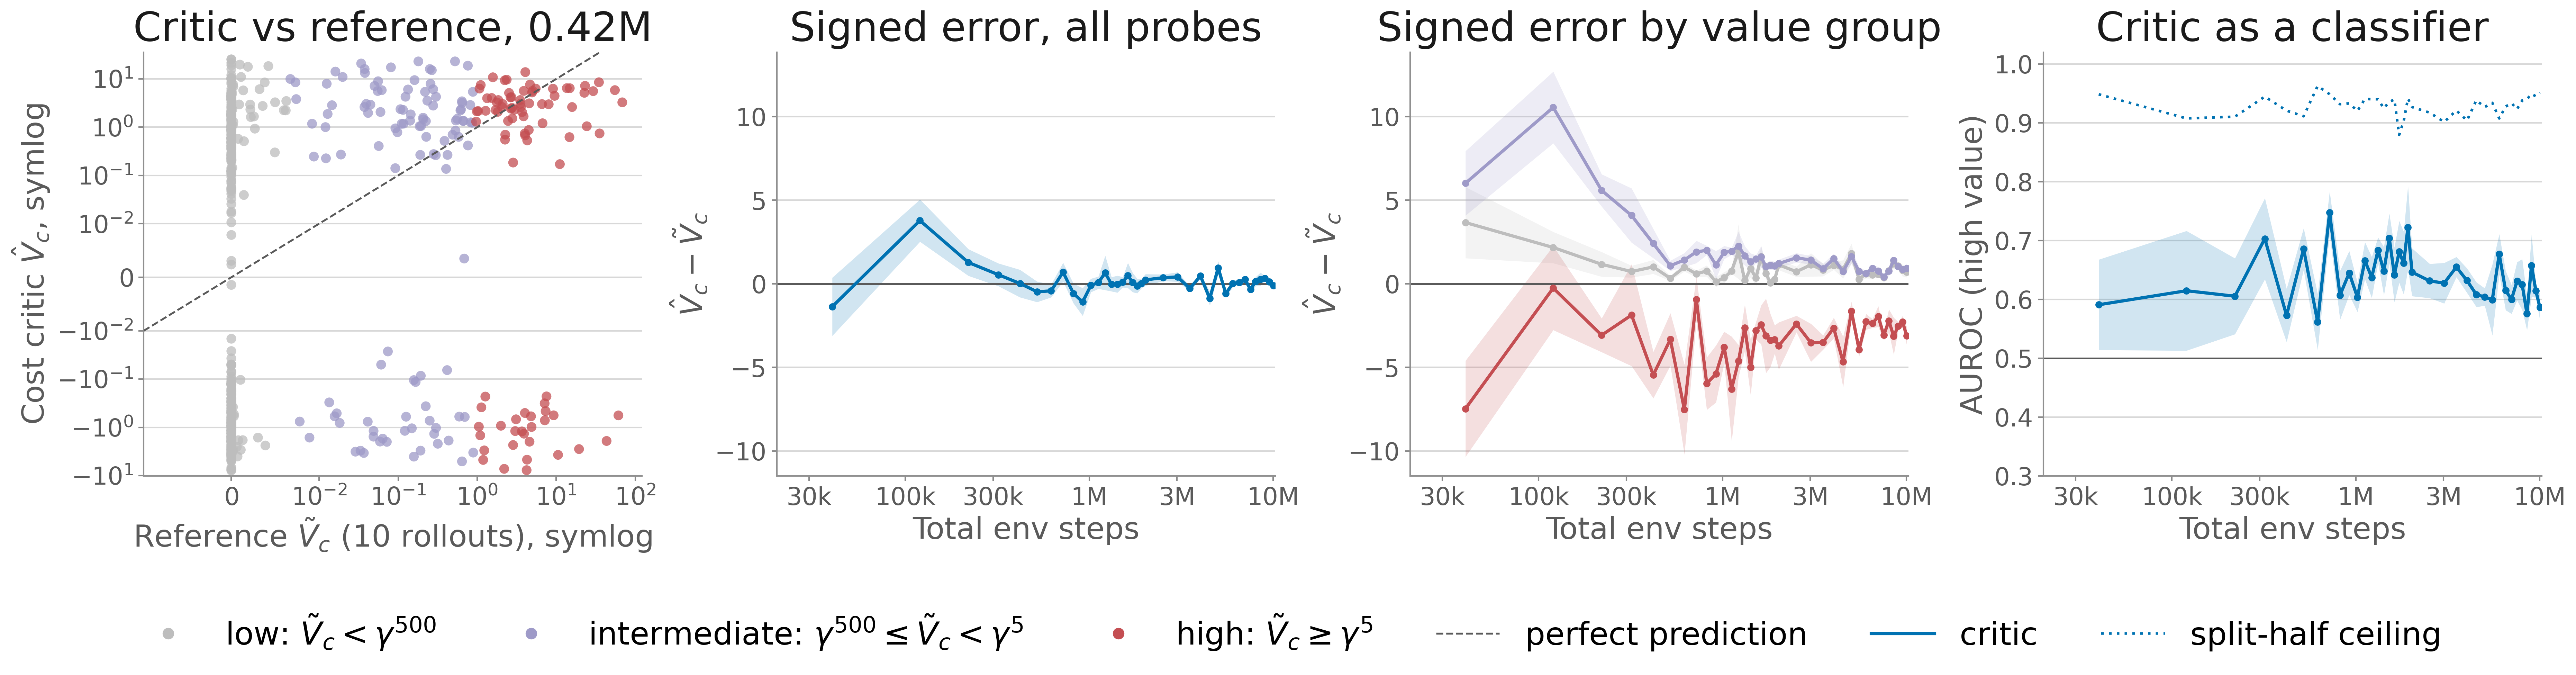

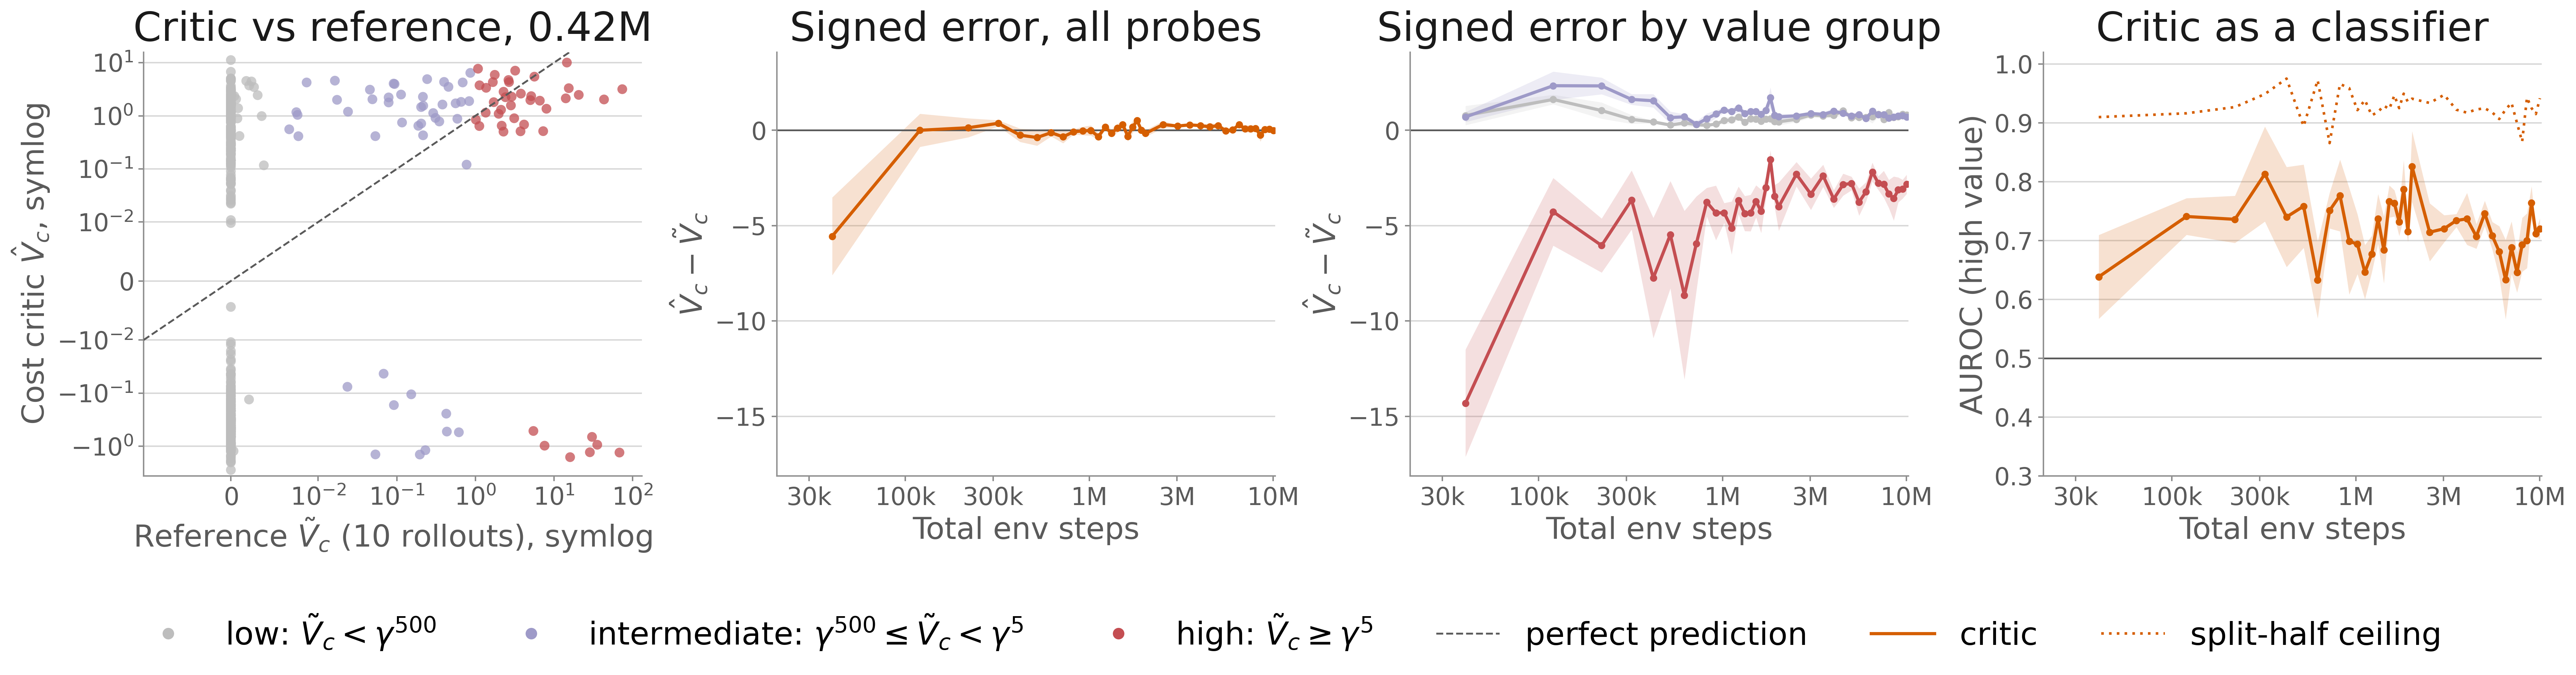

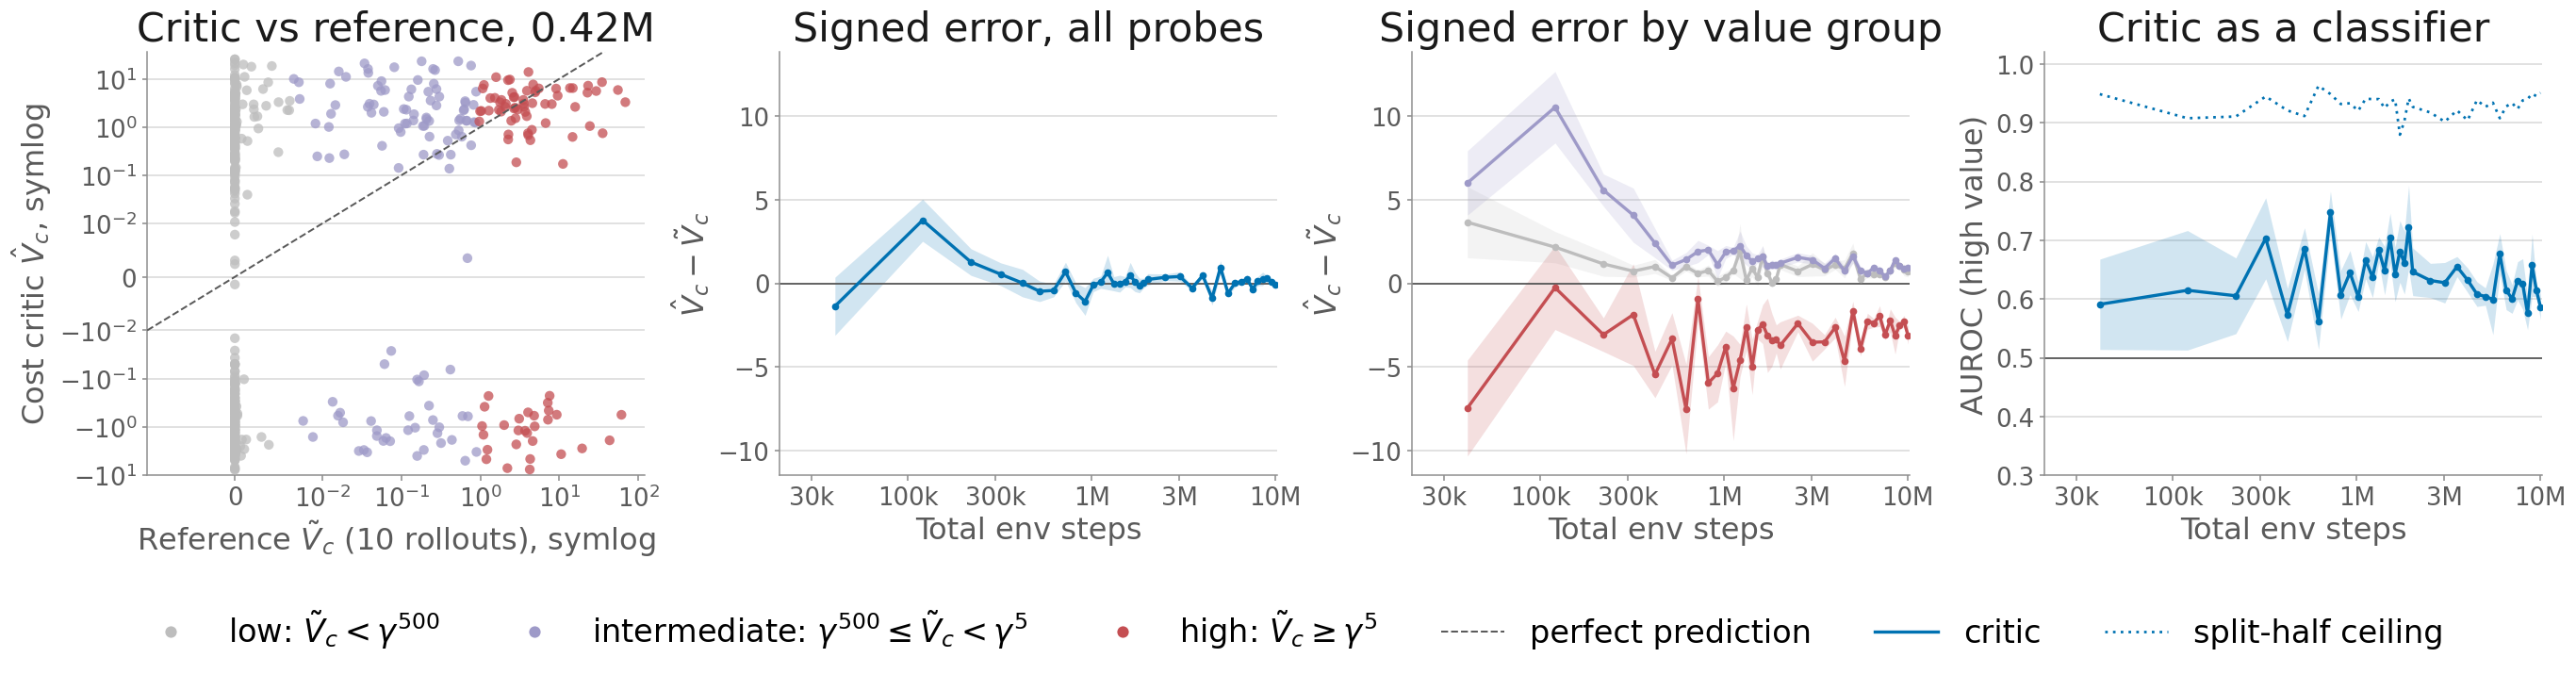

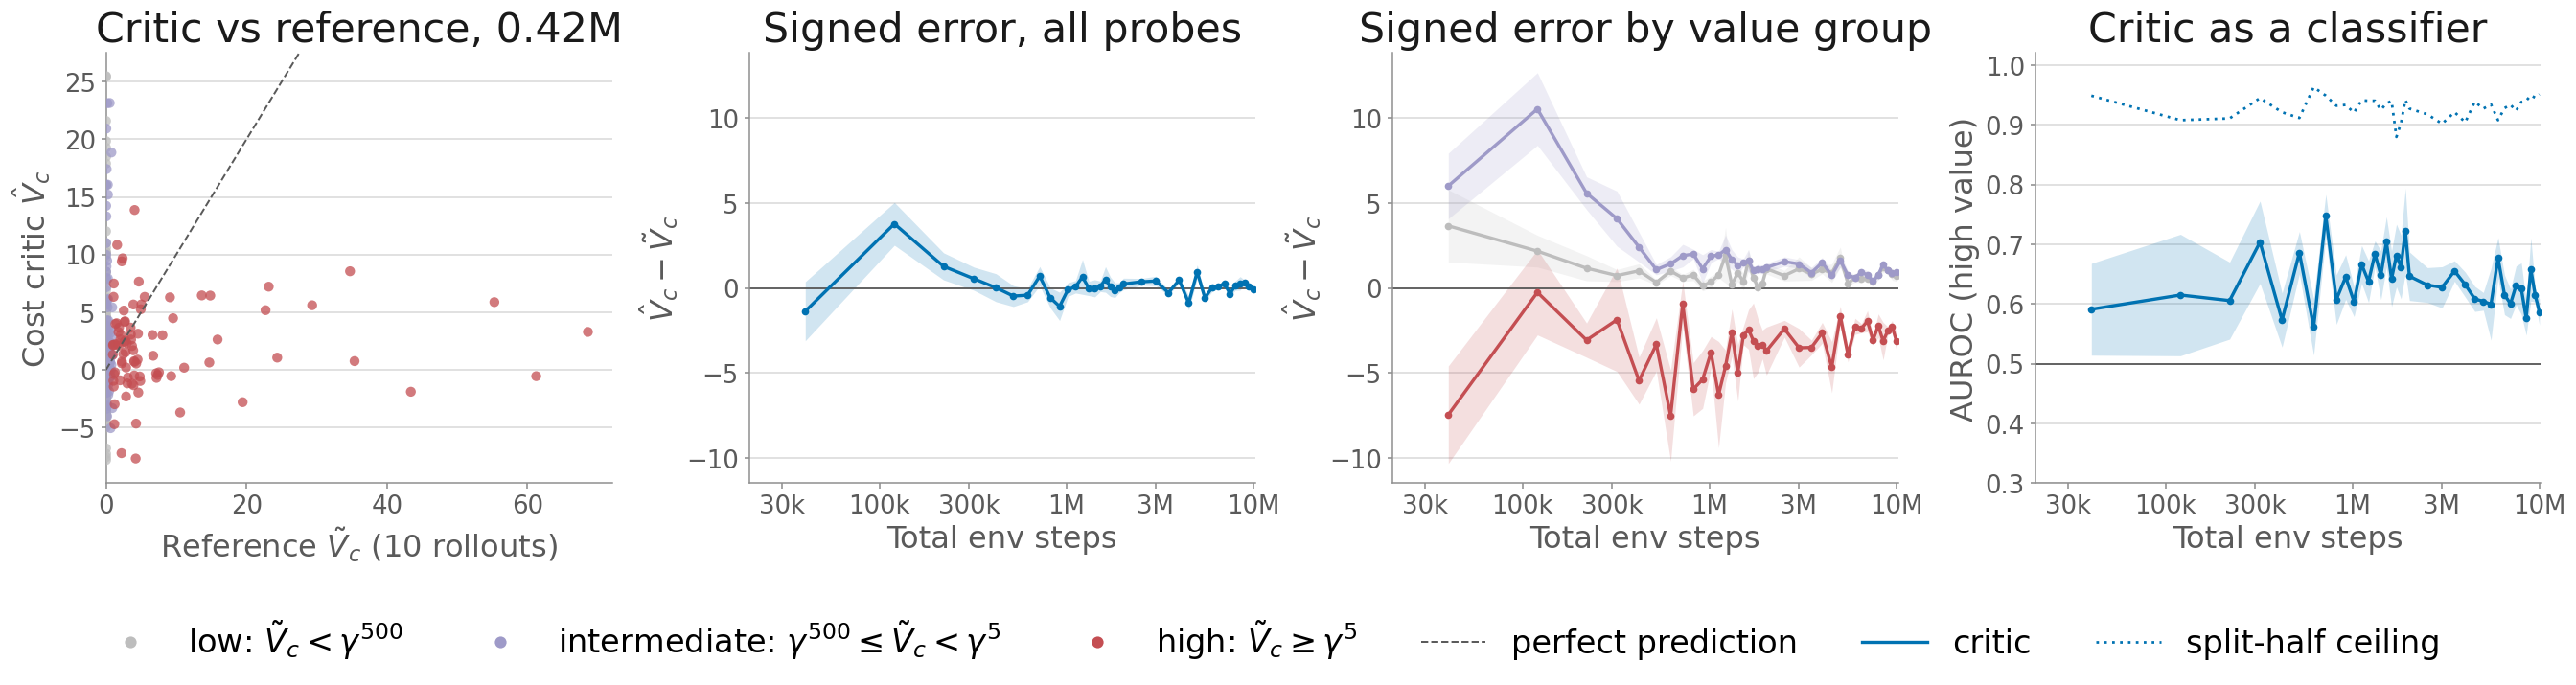

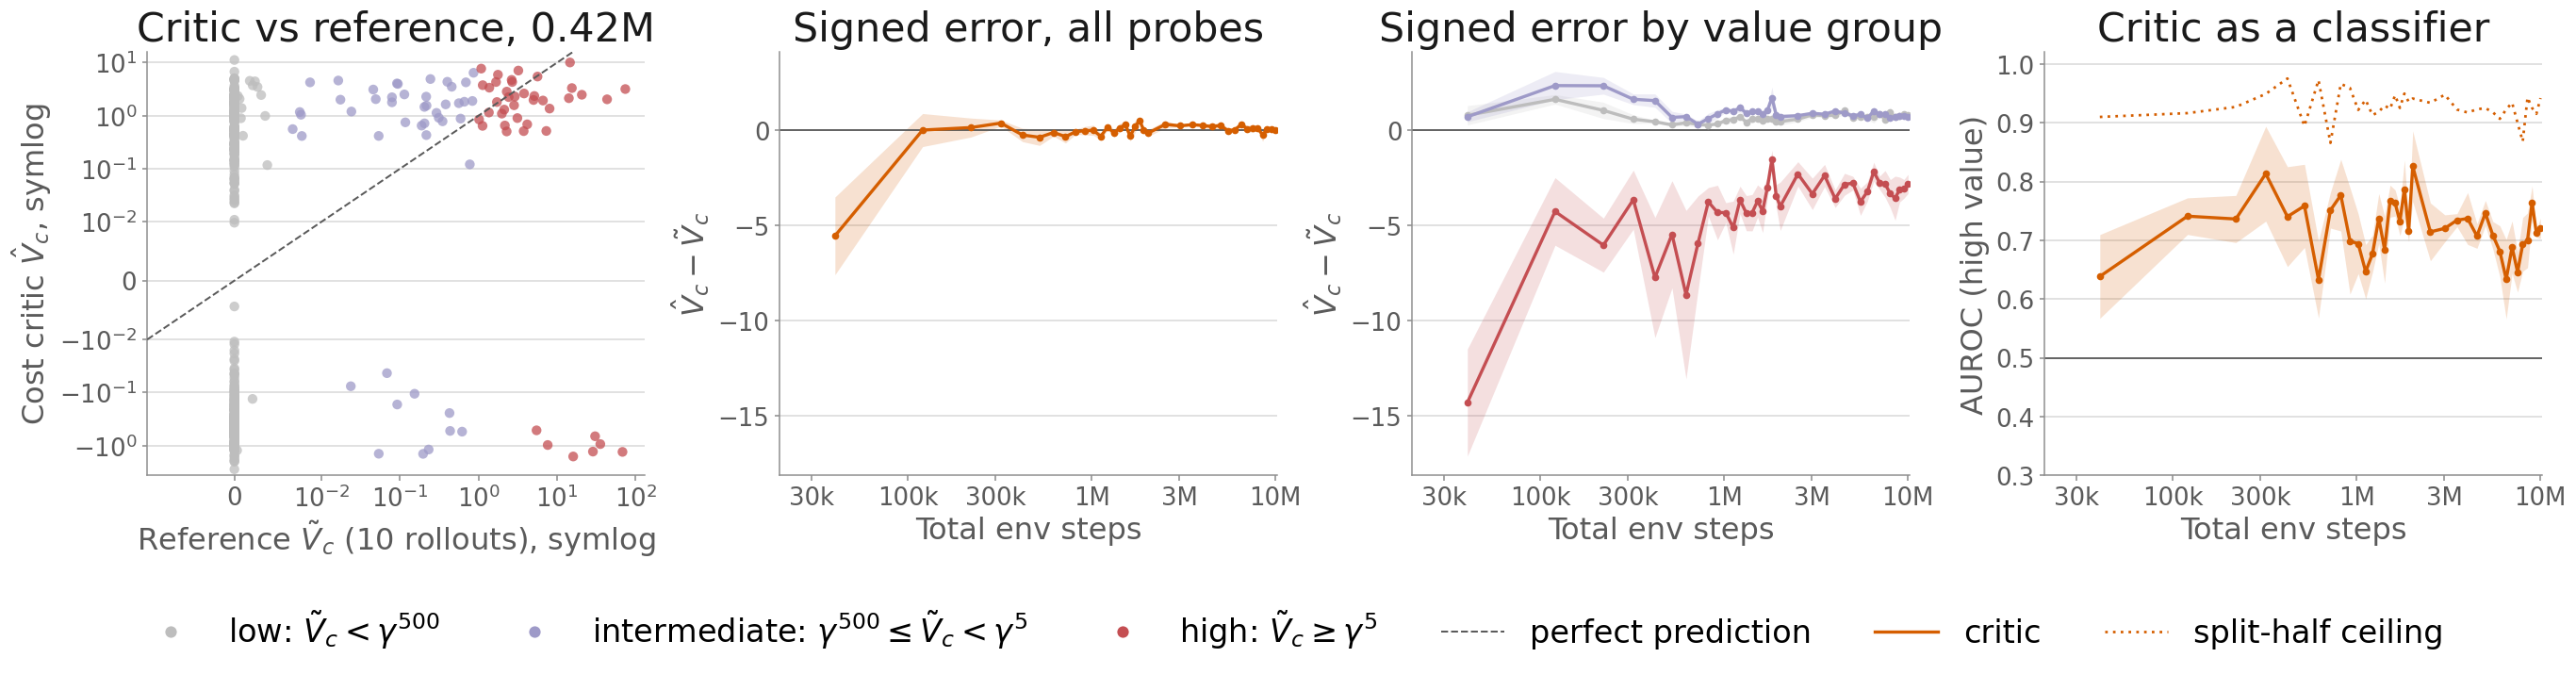

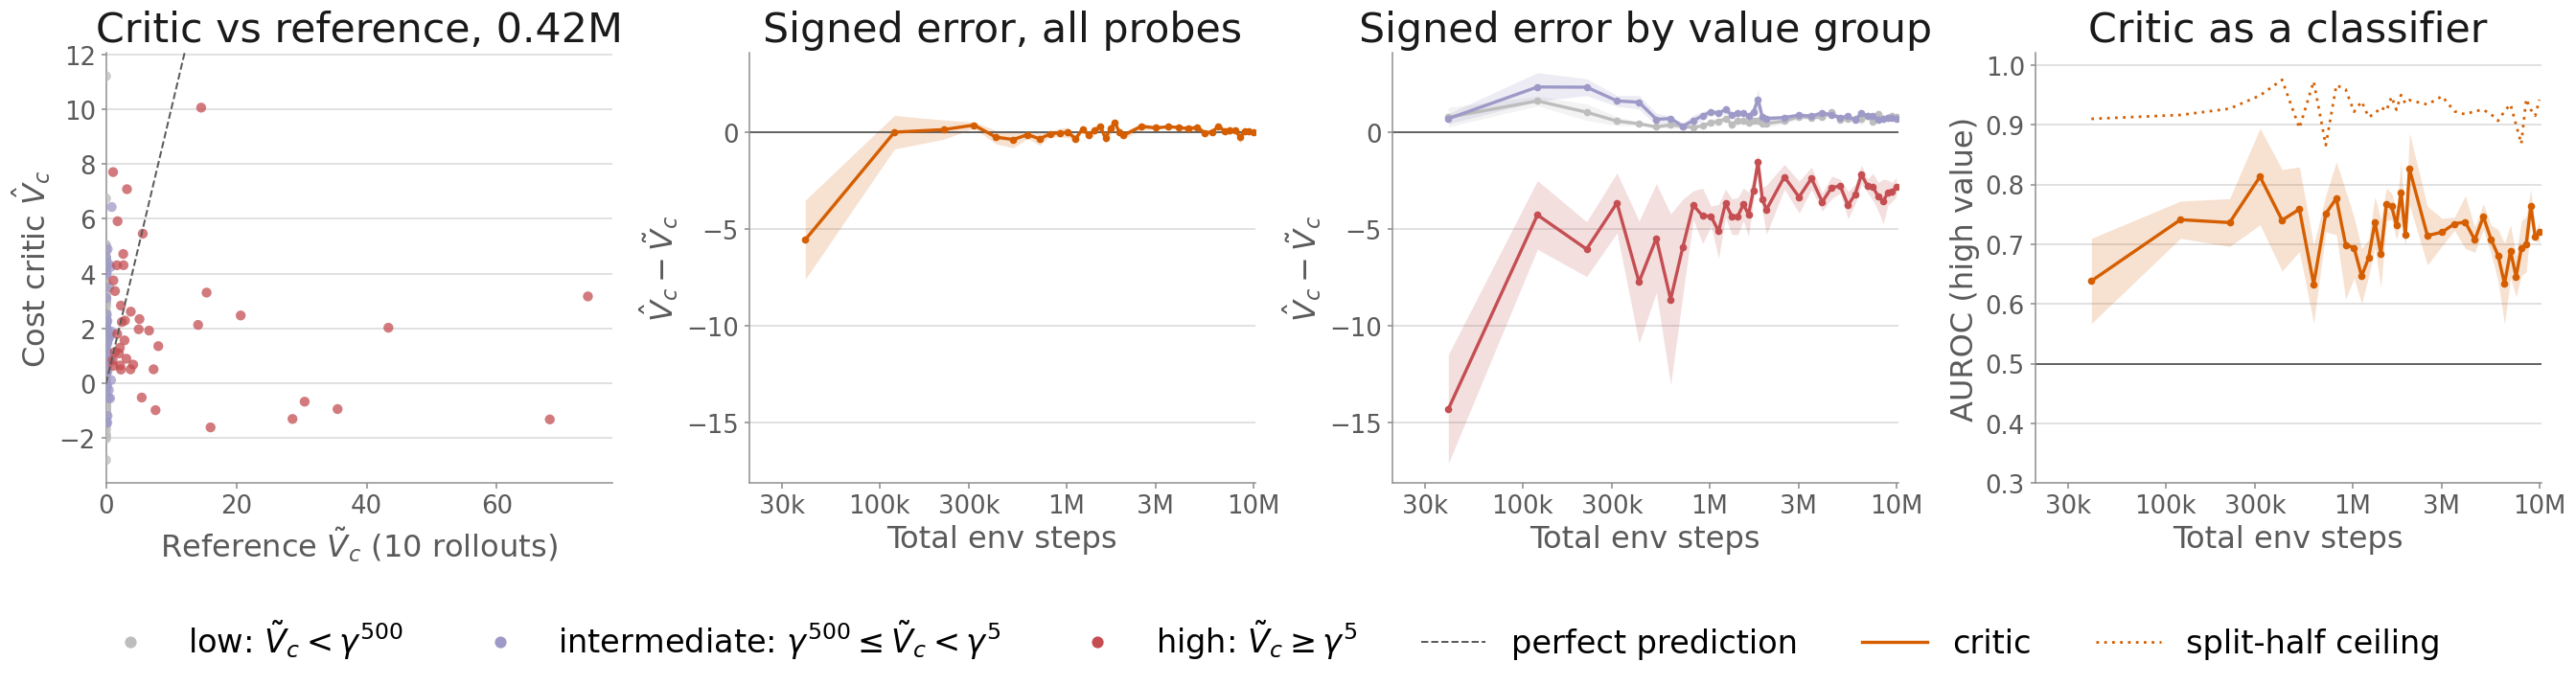

In [11]:
FIG2 = {
    "scatter_epoch": 20,       # which checkpoint panel (a) shows
    # Scatter axes, set independently. "linear" | "symlog" | "log".
    #   symlog  linear within +/- linthresh, log outside -- shows zeros and negatives
    #   log     hides non-positive points (the count is reported)
    "scatter_scale": {"x": "symlog", "y": "symlog"},
    "linthresh": 0.01,         # width of the linear window used by symlog
    # None -> limits picked from the data to suit the scale; else (lo, hi) used verbatim
    "scatter_xlim": [-0.01, ],
    "scatter_ylim": None,
    # extra saved variants: any figure_2 kwarg, plus the filename suffix
    "variants": [dict(suffix="_linear", xscale="linear", yscale="linear")],
    # Panels (b) and (c) show the same quantity, so they share one y scale.
    #   "shared" -> the union of what each would autoscale to, so nothing is clipped
    #   (lo, hi) -> used verbatim on both;  None -> each autoscales on its own
    "error_ylim": "shared",
    # Panel (c) in percent mode: the intermediate group runs to ~+4500% while the high
    # group sits near -50%, so on a linear axis one flattens the other onto zero.
    # symlog keeps both readable and still shows the sign.
    "pct_scale": "symlog",          # "symlog" | "linear"
    "pct_linthresh": 10.0,          # width of the linear window around zero, in %
    "pct_denom": "group",           # "group" = each band's own mean; "overall" = all probes
    "pct_floor": 0.0,               # suppress a band whose denominator is below this
    "pct_ylim": None,
    "auroc_ylim": (0.30, 1.02),
    "legend_in": 1.05,         # inches reserved for the common legend
    "legend_ncol": 6,
}


def scatter_axis(ax, which, scale, v, linthresh, lim=None):
    """Set one scatter axis' scale and limits.

    `lim=None` picks limits from the data to suit the scale; otherwise `lim` is used as
    given.  Automatic limits are data-driven about sign: the cost reference is a discounted
    sum of non-negative costs, so it is >= 0 and needs no room below zero, while the critic
    prediction and the reward reference do go negative.

    Returns (hidden_by_scale, outside_limits): points the panel does not show, because a log
    axis cannot draw v <= 0, or because a manual limit clips them.
    """
    set_scale = {"x": ax.set_xscale, "y": ax.set_yscale}[which]
    set_lim = {"x": ax.set_xlim, "y": ax.set_ylim}[which]
    get_lim = {"x": ax.get_xlim, "y": ax.get_ylim}[which]

    if scale == "log":
        if lim is not None and min(lim) <= 0:
            raise ValueError(f"{which}lim={lim} invalid on a log axis: needs both > 0")
        set_scale("log")
    elif scale == "symlog":
        set_scale("symlog", linthresh=linthresh)
    else:
        set_scale("linear")

    if lim is not None:
        set_lim(*lim)
    elif scale == "log":
        pos = v[v > 0]
        set_lim(pos.min() / 1.8, pos.max() * 1.8)
    elif scale == "symlog":
        # A non-negative quantity needs only a sliver below zero, enough to draw the zeros;
        # a whole decade there would waste a third of the axis on empty space.
        lo = min(v.min() * 1.3, -linthresh * 3) if v.min() < 0 else -linthresh * 0.35
        set_lim(lo, v.max() * 1.4)
    else:
        pad = 0.06 * float(np.ptp(v))
        set_lim(v.min() - (pad or 1.0), v.max() + (pad or 1.0))

    drawable = v > 0 if scale == "log" else np.ones(v.shape, bool)
    lo, hi = get_lim()
    return int((~drawable).sum()), int(((v < lo) | (v > hi))[drawable].sum())


def signed_error_by_group(pred, G):
    """Mean signed error overall and within each true-value group, plus group shares."""
    gbar = G.mean(-1)
    e = pred - gbar
    masks = value_groups(gbar)
    return ([float(e.mean())]
            + [float(e[m].mean()) if m.any() else np.nan for m in masks]
            + [float(m.mean()) for m in masks])


def relative_error_by_group(pred, G, floor=None, denom=None):
    """Signed error within each value group, as a percentage.

    `denom` chooses what the error is a percentage *of*:

    "group"   -- that group's own mean reference.  Answers "by what fraction is this band
                 of states mis-priced".  Well defined everywhere, but for the low group
                 the denominator is of order 1e-4, because most of its probes cost
                 exactly nothing, so the ratio runs to 1e4-1e7 % and is set by the two or
                 three probes a hair above zero rather than by the critic.
    "overall" -- the mean reference over all probes.  One scale for all three groups, so
                 they are directly comparable and none has an unstable denominator.

    `floor` suppresses a group whose denominator is below it, as NaN.  The default of 0
    suppresses nothing: a huge value is still a real one, and on a symlog axis it plots.
    """
    floor = 0.0 if floor is None else floor
    denom = "group" if denom is None else denom
    gbar = G.mean(-1)
    e = pred - gbar
    overall = float(gbar.mean())
    out = []
    for m in value_groups(gbar):
        if not m.any():
            out.append(np.nan)
            continue
        den = float(gbar[m].mean()) if denom == "group" else overall
        out.append(float(100.0 * e[m].mean() / den) if abs(den) > max(floor, 0.0)
                   else np.nan)
    return out


def auroc_high(pred, G):
    return auroc(pred, G.mean(-1) >= T_HIGH)


def auroc_ceiling(pred, G):
    """What a second reference of the same size scores -- the attainable AUROC."""
    K = G.shape[1]
    h1, h2 = G[:, :K // 2].mean(1), G[:, K // 2:].mean(1)
    return float(np.nanmean([auroc(h1, h2 >= T_HIGH), auroc(h2, h1 >= T_HIGH)]))


def figure_2(algo, disp, xscale=None, yscale=None, xlim=None, ylim=None,
             group_mode="absolute"):
    """The four cost-critic panels.

    `group_mode` picks what panel (c) shows: "absolute" the signed error in cost units,
    "percent" that error as a share of each group's own mean reference.  In percent mode
    (b) and (c) carry different units, so they are not put on a shared scale.
    """
    d, col = DATA[algo], ALGO_COLOR[disp]
    gcols = STYLE["groups"]
    L, ink = STYLE["line"], STYLE["ink"]
    xscale = xscale or FIG2["scatter_scale"]["x"]
    yscale = yscale or FIG2["scatter_scale"]["y"]
    xlim = FIG2["scatter_xlim"] if xlim is None else xlim
    ylim = FIG2["scatter_ylim"] if ylim is None else ylim
    fig, ax = make_axes(4, legend_in=FIG2["legend_in"])

    # (a) critic vs reference, pooled over seeds at one checkpoint
    t = int(np.argmin(np.abs(d["epochs"] - FIG2["scatter_epoch"])))
    pred = d["pred_c"][:, t].ravel()
    gbar = d["G_c"][:, t].mean(-1).ravel()
    for m, gc in zip(value_groups(gbar), gcols):
        ax[0].scatter(gbar[m], pred[m], s=L["scatter_size"], color=gc,
                      alpha=L["scatter_alpha"], edgecolors="none", zorder=3)
    nx = scatter_axis(ax[0], "x", xscale, gbar, FIG2["linthresh"], xlim)
    ny = scatter_axis(ax[0], "y", yscale, pred, FIG2["linthresh"], ylim)
    for axis_name, scale, v, (n_scale, n_out) in (("x", xscale, gbar, nx),
                                                  ("y", yscale, pred, ny)):
        if n_scale or n_out:
            why = []
            if n_scale:
                why.append(f"{n_scale} not drawable on a log axis "
                           f"({int((v == 0).sum())} zero, {int((v < 0).sum())} negative)")
            if n_out:
                why.append(f"{n_out} outside the set limits")
            print(f"  {disp} scatter {axis_name}={scale}: {len(v)} points, hides "
                  + "; ".join(why))
    # identity line sampled across the final visible range, so it is right for any scale
    x0, x1 = ax[0].get_xlim()
    xs = np.linspace(x0, x1, 1000)
    ax[0].plot(xs, xs, color=ink["rule"], ls="--", lw=1.3, zorder=4)
    ax[0].set_xlim(x0, x1)
    ax[0].set_xlabel(TEXT["scatter_x"] + SCALE_NOTE[xscale])
    ax[0].set_ylabel(TEXT["scatter_y"] + SCALE_NOTE[yscale])
    ax[0].set_title(f"{TEXT['fig2_titles'][0]}, {d['steps'][t]/1e6:.2f}M")

    # (b)/(c) signed error, overall and by group
    S = np.array([[signed_error_by_group(d["pred_c"][s, t], d["G_c"][s, t])
                   for t in range(len(d["steps"]))] for s in range(len(d["seeds"]))])
    band(ax[1], d["steps"], S[:, :, 0], col, marker="o")
    ax[1].axhline(0, color=ink["rule"], lw=1.2, zorder=2)
    ax[1].set_ylabel(TEXT["error_y"])
    if group_mode == "percent":
        P = np.array([[relative_error_by_group(d["pred_c"][s, t], d["G_c"][s, t],
                                               floor=FIG2["pct_floor"],
                                               denom=FIG2["pct_denom"])
                       for t in range(len(d["steps"]))] for s in range(len(d["seeds"]))])
        for i, gc in enumerate(gcols):
            if np.isfinite(P[:, :, i]).any():
                band(ax[2], d["steps"], P[:, :, i], gc, marker="o")
        dropped = [TEXT["groups"][i] for i in range(3)
                   if not np.isfinite(P[:, :, i]).any()]
        if dropped:
            print(f"  {disp}: {dropped} suppressed by pct_floor={FIG2['pct_floor']:g}")
        ax[2].set_ylabel(TEXT["error_pct_y"])
        if FIG2["pct_scale"] == "symlog":
            ax[2].set_yscale("symlog", linthresh=FIG2["pct_linthresh"])
            ax[2].yaxis.set_minor_locator(mticker.NullLocator())
        if FIG2["pct_ylim"]:
            ax[2].set_ylim(*FIG2["pct_ylim"])
    elif group_mode == "absolute":
        for i, gc in enumerate(gcols):
            band(ax[2], d["steps"], S[:, :, 1 + i], gc, marker="o")
        ax[2].set_ylabel(TEXT["error_y"])
    else:
        raise ValueError(f'group_mode must be "absolute" or "percent"; got {group_mode!r}')
    ax[2].axhline(0, color=ink["rule"], lw=1.2, zorder=2)

    # One scale across (b) and (c): a swing in the by-group panel says nothing about
    # size if it is read against a different axis from the pooled one.
    # (b) is in cost units; in percent mode (c) is not, so they cannot share an axis
    share = FIG2["error_ylim"] if group_mode == "absolute" else None
    if share == "shared":
        lims = [ax[1].get_ylim(), ax[2].get_ylim()]
        share = (min(lo for lo, _ in lims), max(hi for _, hi in lims))
    if share is not None:
        ax[1].set_ylim(*share)
        ax[2].set_ylim(*share)

    # (d) the critic as a classifier, against the split-half ceiling
    band(ax[3], d["steps"], map_checkpoints(d, "c", auroc_high), col, marker="o")
    ceil = np.nanmean(map_checkpoints(d, "c", auroc_ceiling), 0)
    ax[3].plot(d["steps"], ceil, color=col, lw=L["ceiling_width"], ls=L["ceiling_dash"],
               zorder=4)
    ax[3].axhline(0.5, color=ink["rule"], lw=1.2, zorder=2)
    ax[3].set_ylim(*FIG2["auroc_ylim"])
    ax[3].set_ylabel(TEXT["auroc_y"])

    titles = list(TEXT["fig2_titles"])
    if group_mode == "percent":
        titles[2] = TEXT["fig2_pct_title"]
    for a, title in zip(ax[1:], titles[1:]):
        a.set_title(title)
        log_steps(a, X_FIRST, X_LAST)

    legend_below(fig, [(dot_key(gcols[i]), TEXT["group_defs"][i]) for i in range(3)]
                 + [(line_key(ink["rule"], lw=1.3, ls="--"), TEXT["identity"]),
                    (line_key(col), TEXT["critic"]),
                    (line_key(col, lw=L["ceiling_width"], ls=L["ceiling_dash"]),
                     TEXT["ceiling"])],
                 ncol=FIG2["legend_ncol"])
    # fig.suptitle(TEXT["fig2_suptitle"].format(algo=disp),
    #              fontsize=STYLE["font"]["suptitle"], color=ink["title"], y=1.02)
    return fig


for algo, disp in ALGOS:
    stem = f"fig2_{disp.lower()}"
    save(figure_2(algo, disp), stem)
    for var in FIG2["variants"]:
        kw = {k: v for k, v in var.items() if k != "suffix"}
        save(figure_2(algo, disp, **kw), stem + var["suffix"])
show(*[f"fig2_{disp.lower()}" for _, disp in ALGOS])

### 6.1 Linear scatter, zoomed near a zero reference

Figure 2's scatter is symlog, which spreads the near-zero probes across several decades and
makes the critic look better behaved there than it is. This pair is plain **linear**: the
full range on the left, and on the right a zoom on $\tilde V_c \approx 0$ — the states the
Monte-Carlo reference says cost nothing.

That region matters because about 30% of probes have a reference of *exactly* zero, so it is
where over-prediction is cheapest to spot: every point above the dashed identity line is the
critic charging cost to a state the simulator says is free. The dashed rectangle on the left
marks what the right panel shows.

  CPO: 422/510 probes inside the zoom window; 261 have a reference of exactly 0, and there the critic predicts median +0.04 (IQR -0.74 to +1.00), 53% of them positive
saved: fig2_zoom_cpo png/pdf
  PIDLag: 467/510 probes inside the zoom window; 404 have a reference of exactly 0, and there the critic predicts median -0.02 (IQR -0.40 to +0.81), 49% of them positive
saved: fig2_zoom_pidlag png/pdf


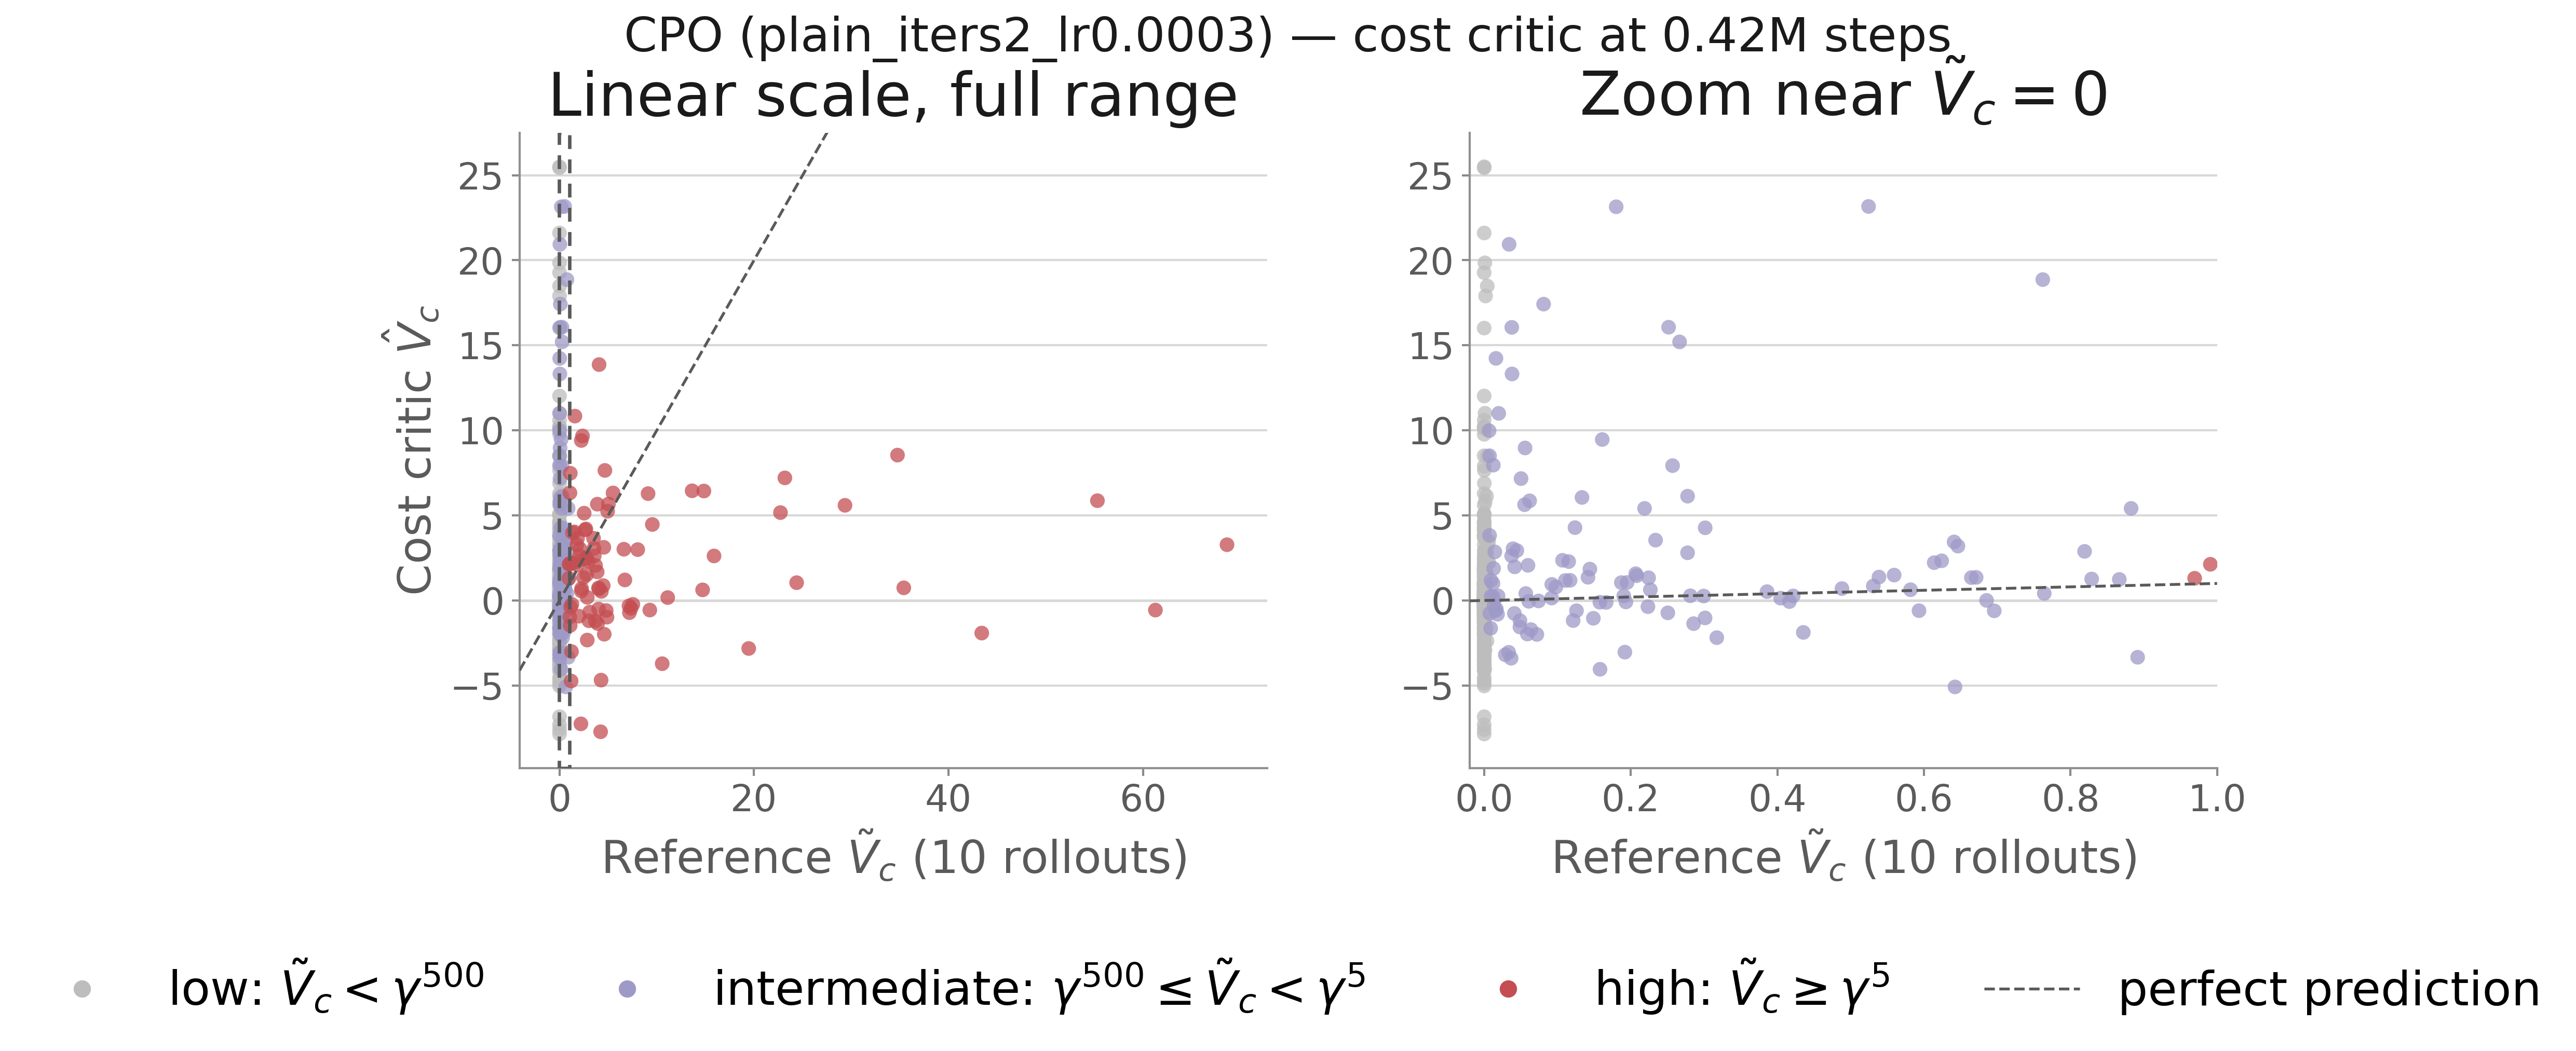

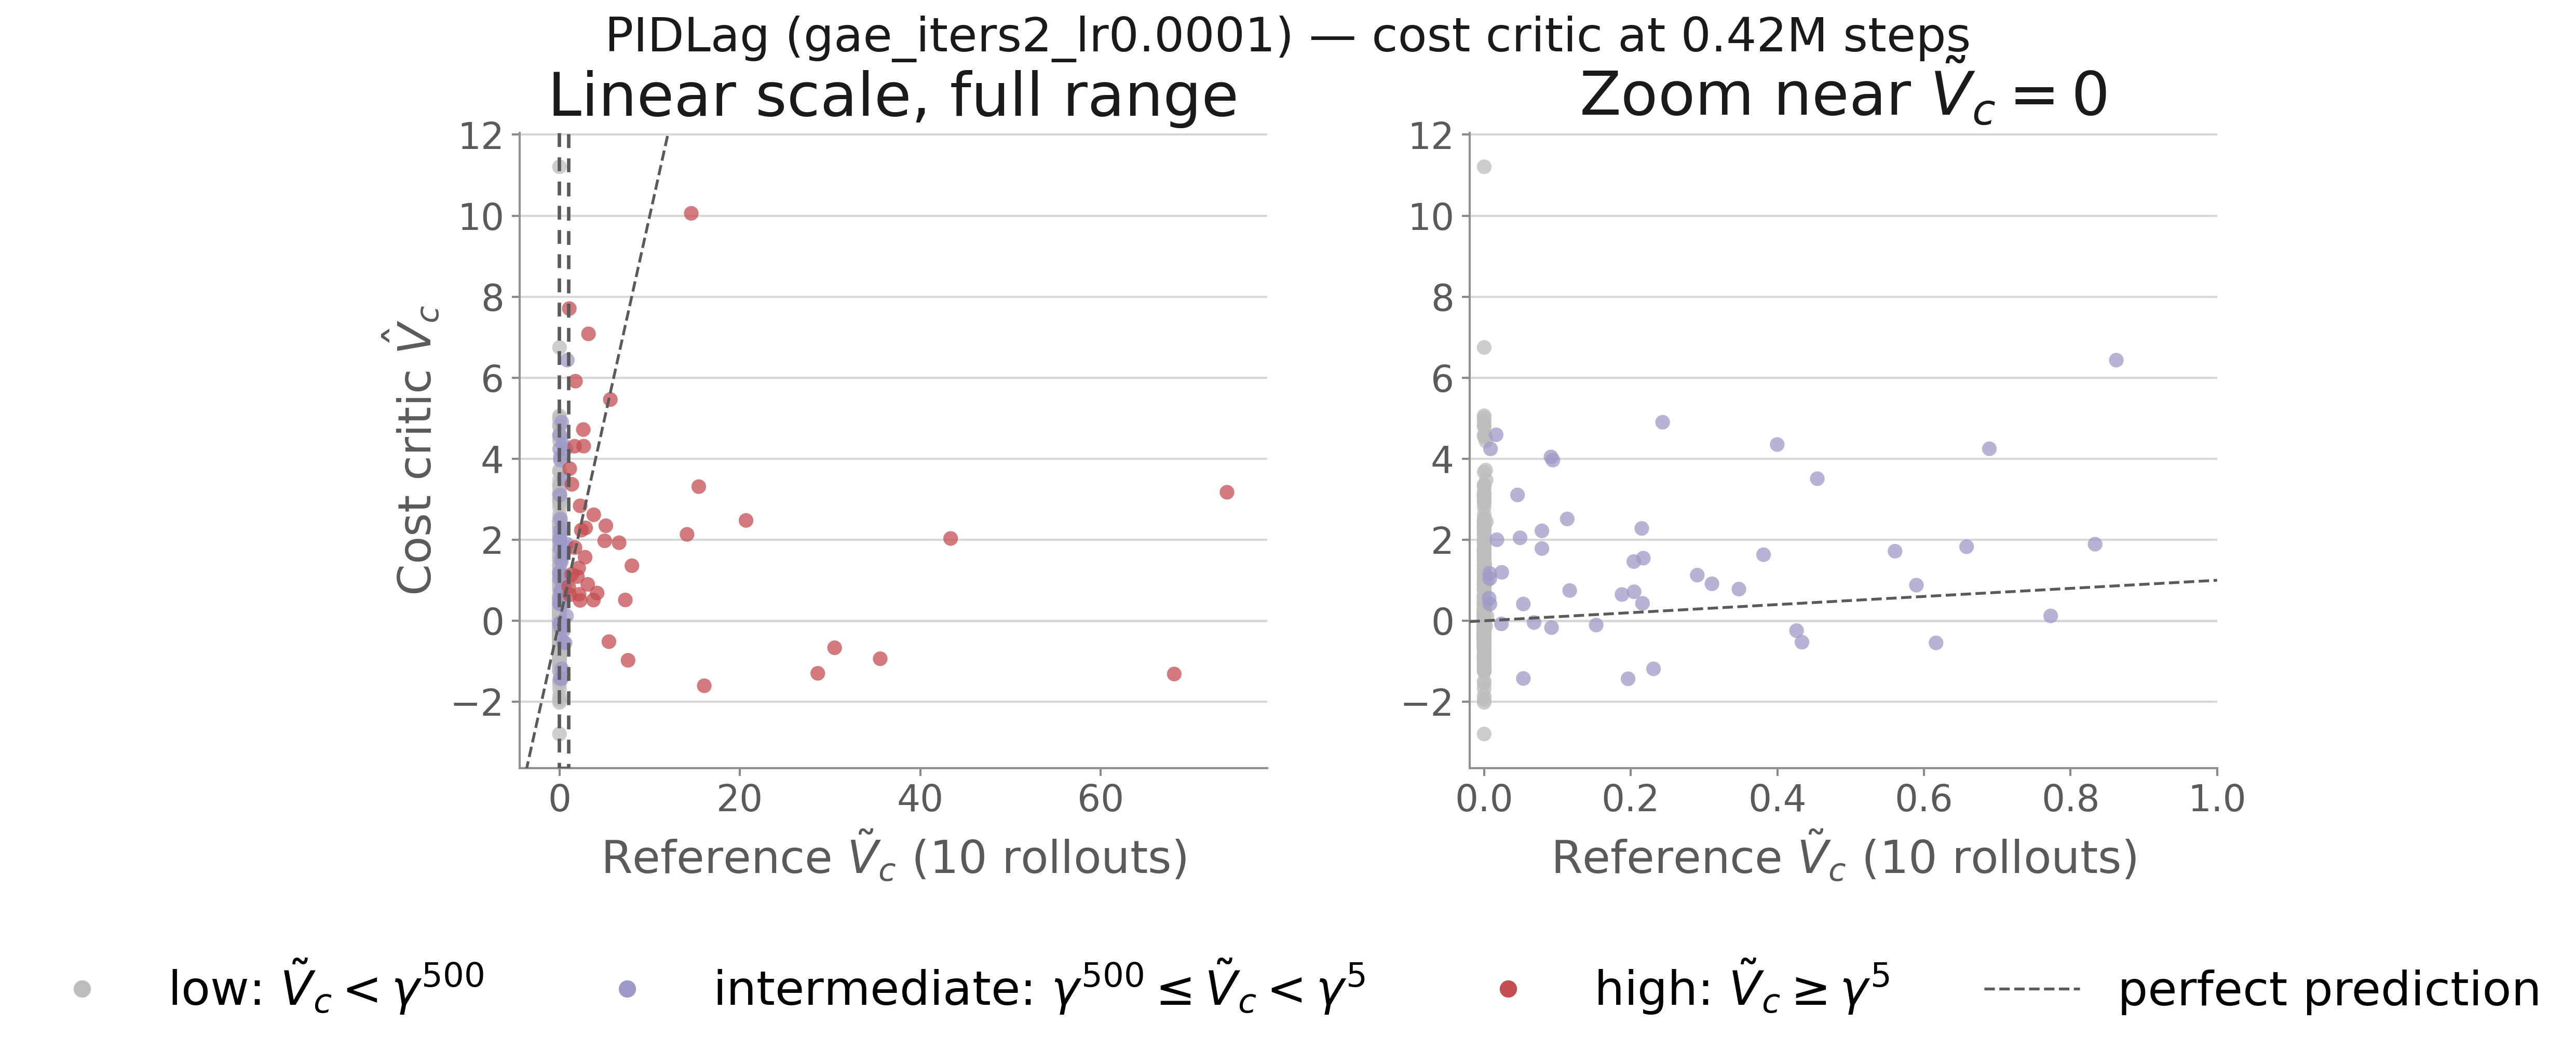

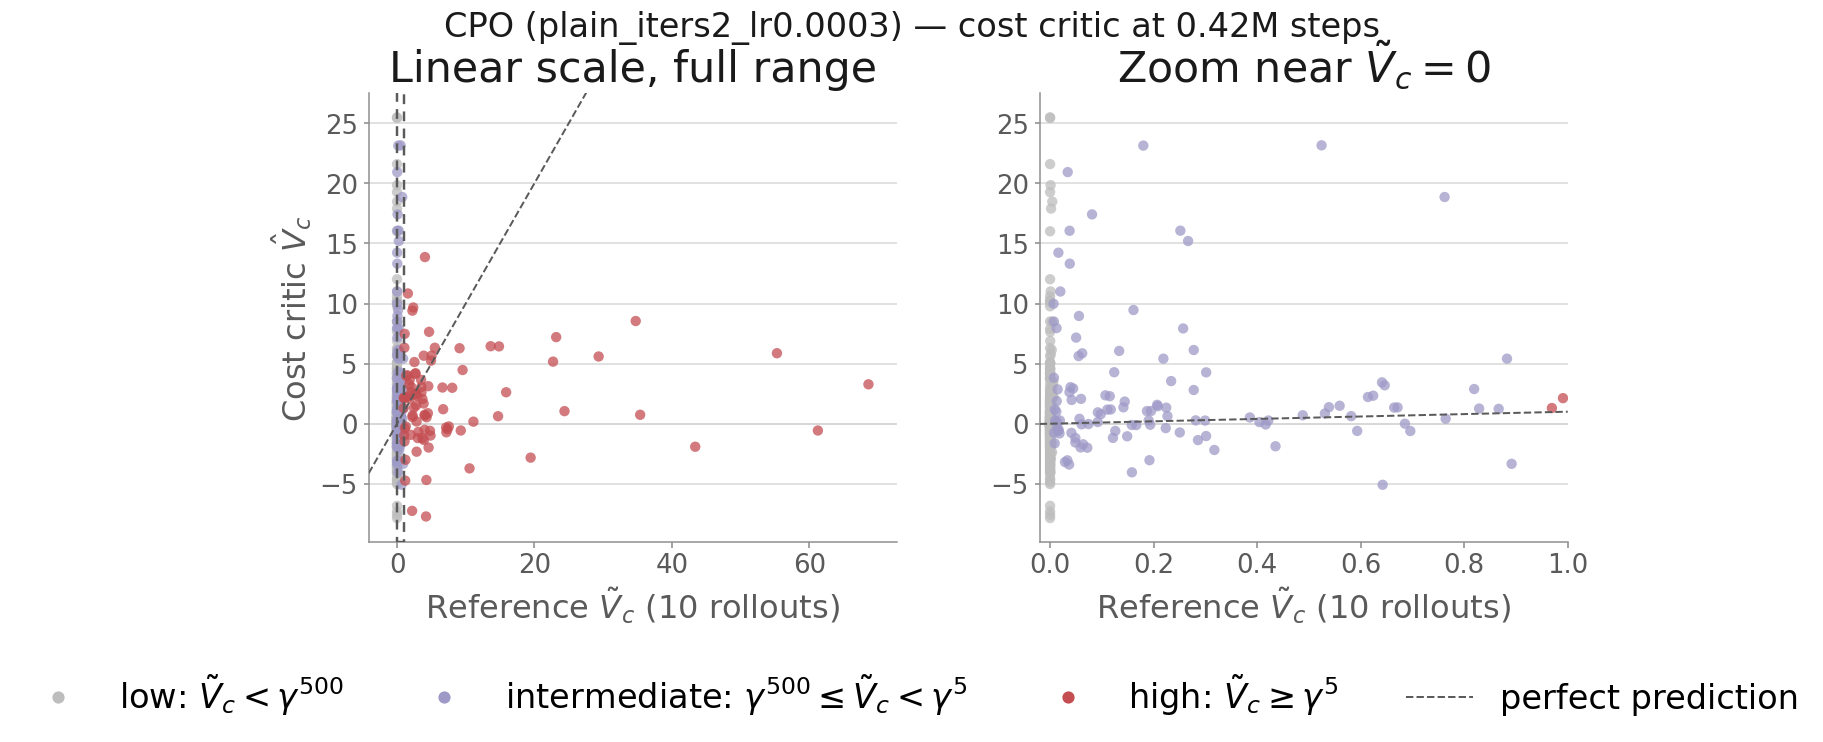

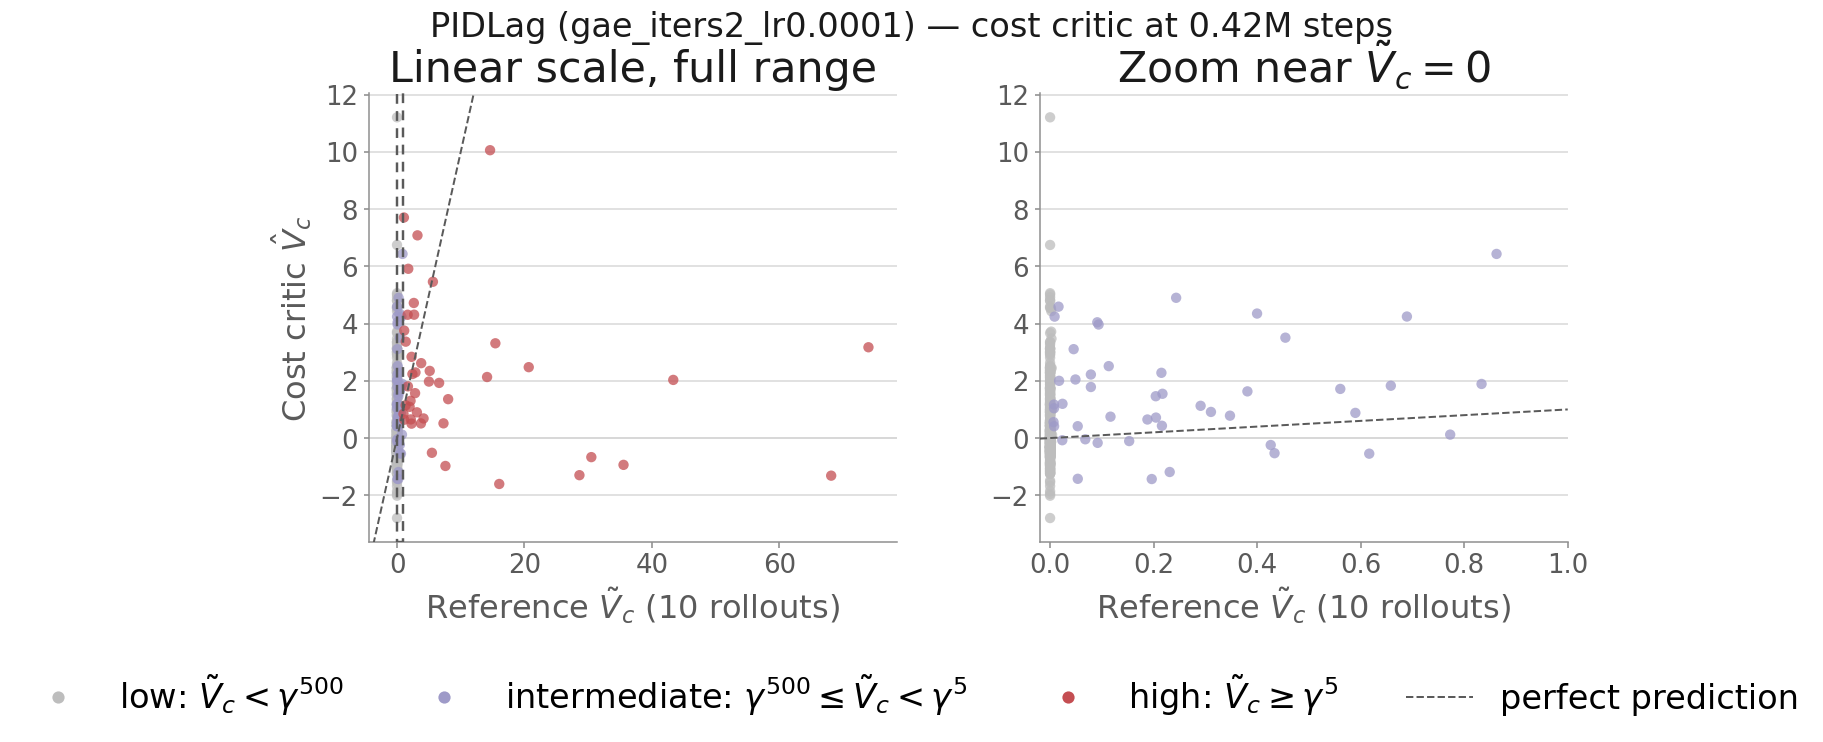

In [12]:
from matplotlib.patches import Rectangle

ZOOM = {
    "epoch": None,                  # None -> FIG2["scatter_epoch"]
    "x_window": (-0.02, 1.0),       # the zoom range, in reference units
    "ylim_full": None,              # None -> from all the data
    "ylim_zoom": None,              # None -> from the points inside x_window
    "mark_region": True,            # draw the zoom rectangle on the full panel
    "jitter": 0.0,                  # x jitter for the zero column, in reference units
    "legend_in": 0.95,
    "title_in": 0.55,
    "titles": ["Linear scale, full range", r"Zoom near $\tilde V_c = 0$"],
}


def linear_lims(v, pad=0.06):
    p = pad * float(np.ptp(v))
    return v.min() - (p or 1.0), v.max() + (p or 1.0)


def figure_scatter_zoom(algo, disp):
    d = DATA[algo]
    gcols, ink, L = STYLE["groups"], STYLE["ink"], STYLE["line"]
    ep = FIG2["scatter_epoch"] if ZOOM["epoch"] is None else ZOOM["epoch"]
    t = int(np.argmin(np.abs(d["epochs"] - ep)))
    pred = d["pred_c"][:, t].ravel()
    gbar = d["G_c"][:, t].mean(-1).ravel()

    # optional jitter only moves the drawn x, never the data used for limits or stats
    rng = np.random.default_rng(0)
    gx = gbar + (rng.uniform(-1, 1, gbar.size) * ZOOM["jitter"] if ZOOM["jitter"] else 0.0)

    lo, hi = ZOOM["x_window"]
    inside = (gbar >= lo) & (gbar <= hi)
    fig, ax = make_axes(2, legend_in=ZOOM["legend_in"],
                        title_in=ZOOM["title_in"])

    for a, zoom in ((ax[0], False), (ax[1], True)):
        for m, gc in zip(value_groups(gbar), gcols):
            a.scatter(gx[m], pred[m], s=L["scatter_size"], color=gc,
                      alpha=L["scatter_alpha"], edgecolors="none", zorder=3)
        a.set_xlim(*(ZOOM["x_window"] if zoom else linear_lims(gbar)))
        yl = ZOOM["ylim_zoom"] if zoom else ZOOM["ylim_full"]
        if yl is None:
            yl = linear_lims(pred[inside] if zoom else pred)
        a.set_ylim(*yl)
        x0, x1 = a.get_xlim()
        xs = np.linspace(x0, x1, 500)
        a.plot(xs, xs, color=ink["rule"], ls="--", lw=1.3, zorder=4)   # identity
        a.axhline(0, color=ink["grid"], lw=1.2, zorder=1)
        a.set_xlim(x0, x1)
        a.set_xlabel(TEXT["scatter_x"])

    if ZOOM["mark_region"]:
        y0, y1 = ax[1].get_ylim()
        ax[0].add_patch(Rectangle((lo, y0), hi - lo, y1 - y0, fill=False,
                                  edgecolor=ink["rule"], lw=1.6, ls=(0, (4, 3)), zorder=5))

    ax[0].set_ylabel(TEXT["scatter_y"])
    for a, title in zip(ax, ZOOM["titles"]):
        a.set_title(title)

    legend_below(fig, [(dot_key(gcols[i]), TEXT["group_defs"][i]) for i in range(3)]
                 + [(line_key(ink["rule"], lw=1.3, ls="--"), TEXT["identity"])], ncol=4)
    suptitle(fig, f"{disp} ({d['cell']}) — cost critic at {d['steps'][t]/1e6:.2f}M steps")

    # what the zoom is actually showing
    z = gbar == 0
    n_in = int(inside.sum())
    print(f"  {disp}: {n_in}/{len(gbar)} probes inside the zoom window; "
          f"{int(z.sum())} have a reference of exactly 0, and there the critic predicts "
          f"median {np.median(pred[z]):+.2f} "
          f"(IQR {np.percentile(pred[z], 25):+.2f} to {np.percentile(pred[z], 75):+.2f}), "
          f"{100 * np.mean(pred[z] > 0):.0f}% of them positive")
    return fig


for algo, disp in ALGOS:
    save(figure_scatter_zoom(algo, disp), f"fig2_zoom_{disp.lower()}")
show(*[f"fig2_zoom_{disp.lower()}" for _, disp in ALGOS], width=900)

### 6.2 The same figure, with panel (c) as a percentage

Identical to Figure 2 above except for the third panel, which shows each group's signed error
as a **share of that group's own mean reference** rather than in cost units:

$$100 \times \frac{\overline{\hat V_c} - \overline{\tilde V_c}}{\overline{\tilde V_c}}
\quad\text{within a group}$$

so a point at $+50$ means the critic charges half again as much cost as those states actually
incur, and $-50$ means it sees half the cost they do. That makes the groups comparable to each
other, which the absolute version cannot be: the high group's errors are in whole cost units
while the intermediate group's are fractions of one.

**The low group has no percentage.** Its mean reference is of order $10^{-4}$ — most of its
probes cost exactly nothing — so dividing by it is a ratio to zero rather than a large
number. `relative_error_by_group` returns NaN when a group's mean reference falls below
$\gamma^{500}$, and the cell says which groups that removed.

Panels (b) and (c) are deliberately *not* on a shared y scale here, since one is in cost units
and the other in percent.

In [ ]:
PCT = {
    "floor": None,        # None -> T_LOW; the smallest mean reference worth dividing by
    "variants": [],       # same shape as FIG2["variants"] if extra scales are wanted
}

for algo, disp in ALGOS:
    stem = f"fig2_pct_{disp.lower()}"
    save(figure_2(algo, disp, group_mode="percent"), stem)
    for var in PCT["variants"]:
        kw = {k: v for k, v in var.items() if k != "suffix"}
        save(figure_2(algo, disp, group_mode="percent", **kw), stem + var["suffix"])
show(*[f"fig2_pct_{disp.lower()}" for _, disp in ALGOS])

## 7. Threshold sensitivity

Panel (d) of Figure 2 fixes "high value" at $\tilde V_c \geq \gamma^5$. This sweeps that
threshold, split by training phase, to check the classifier result is not an artefact of
where the cut is drawn. Median over seeds and checkpoints, IQR shaded.

saved: fig2_threshold png/pdf


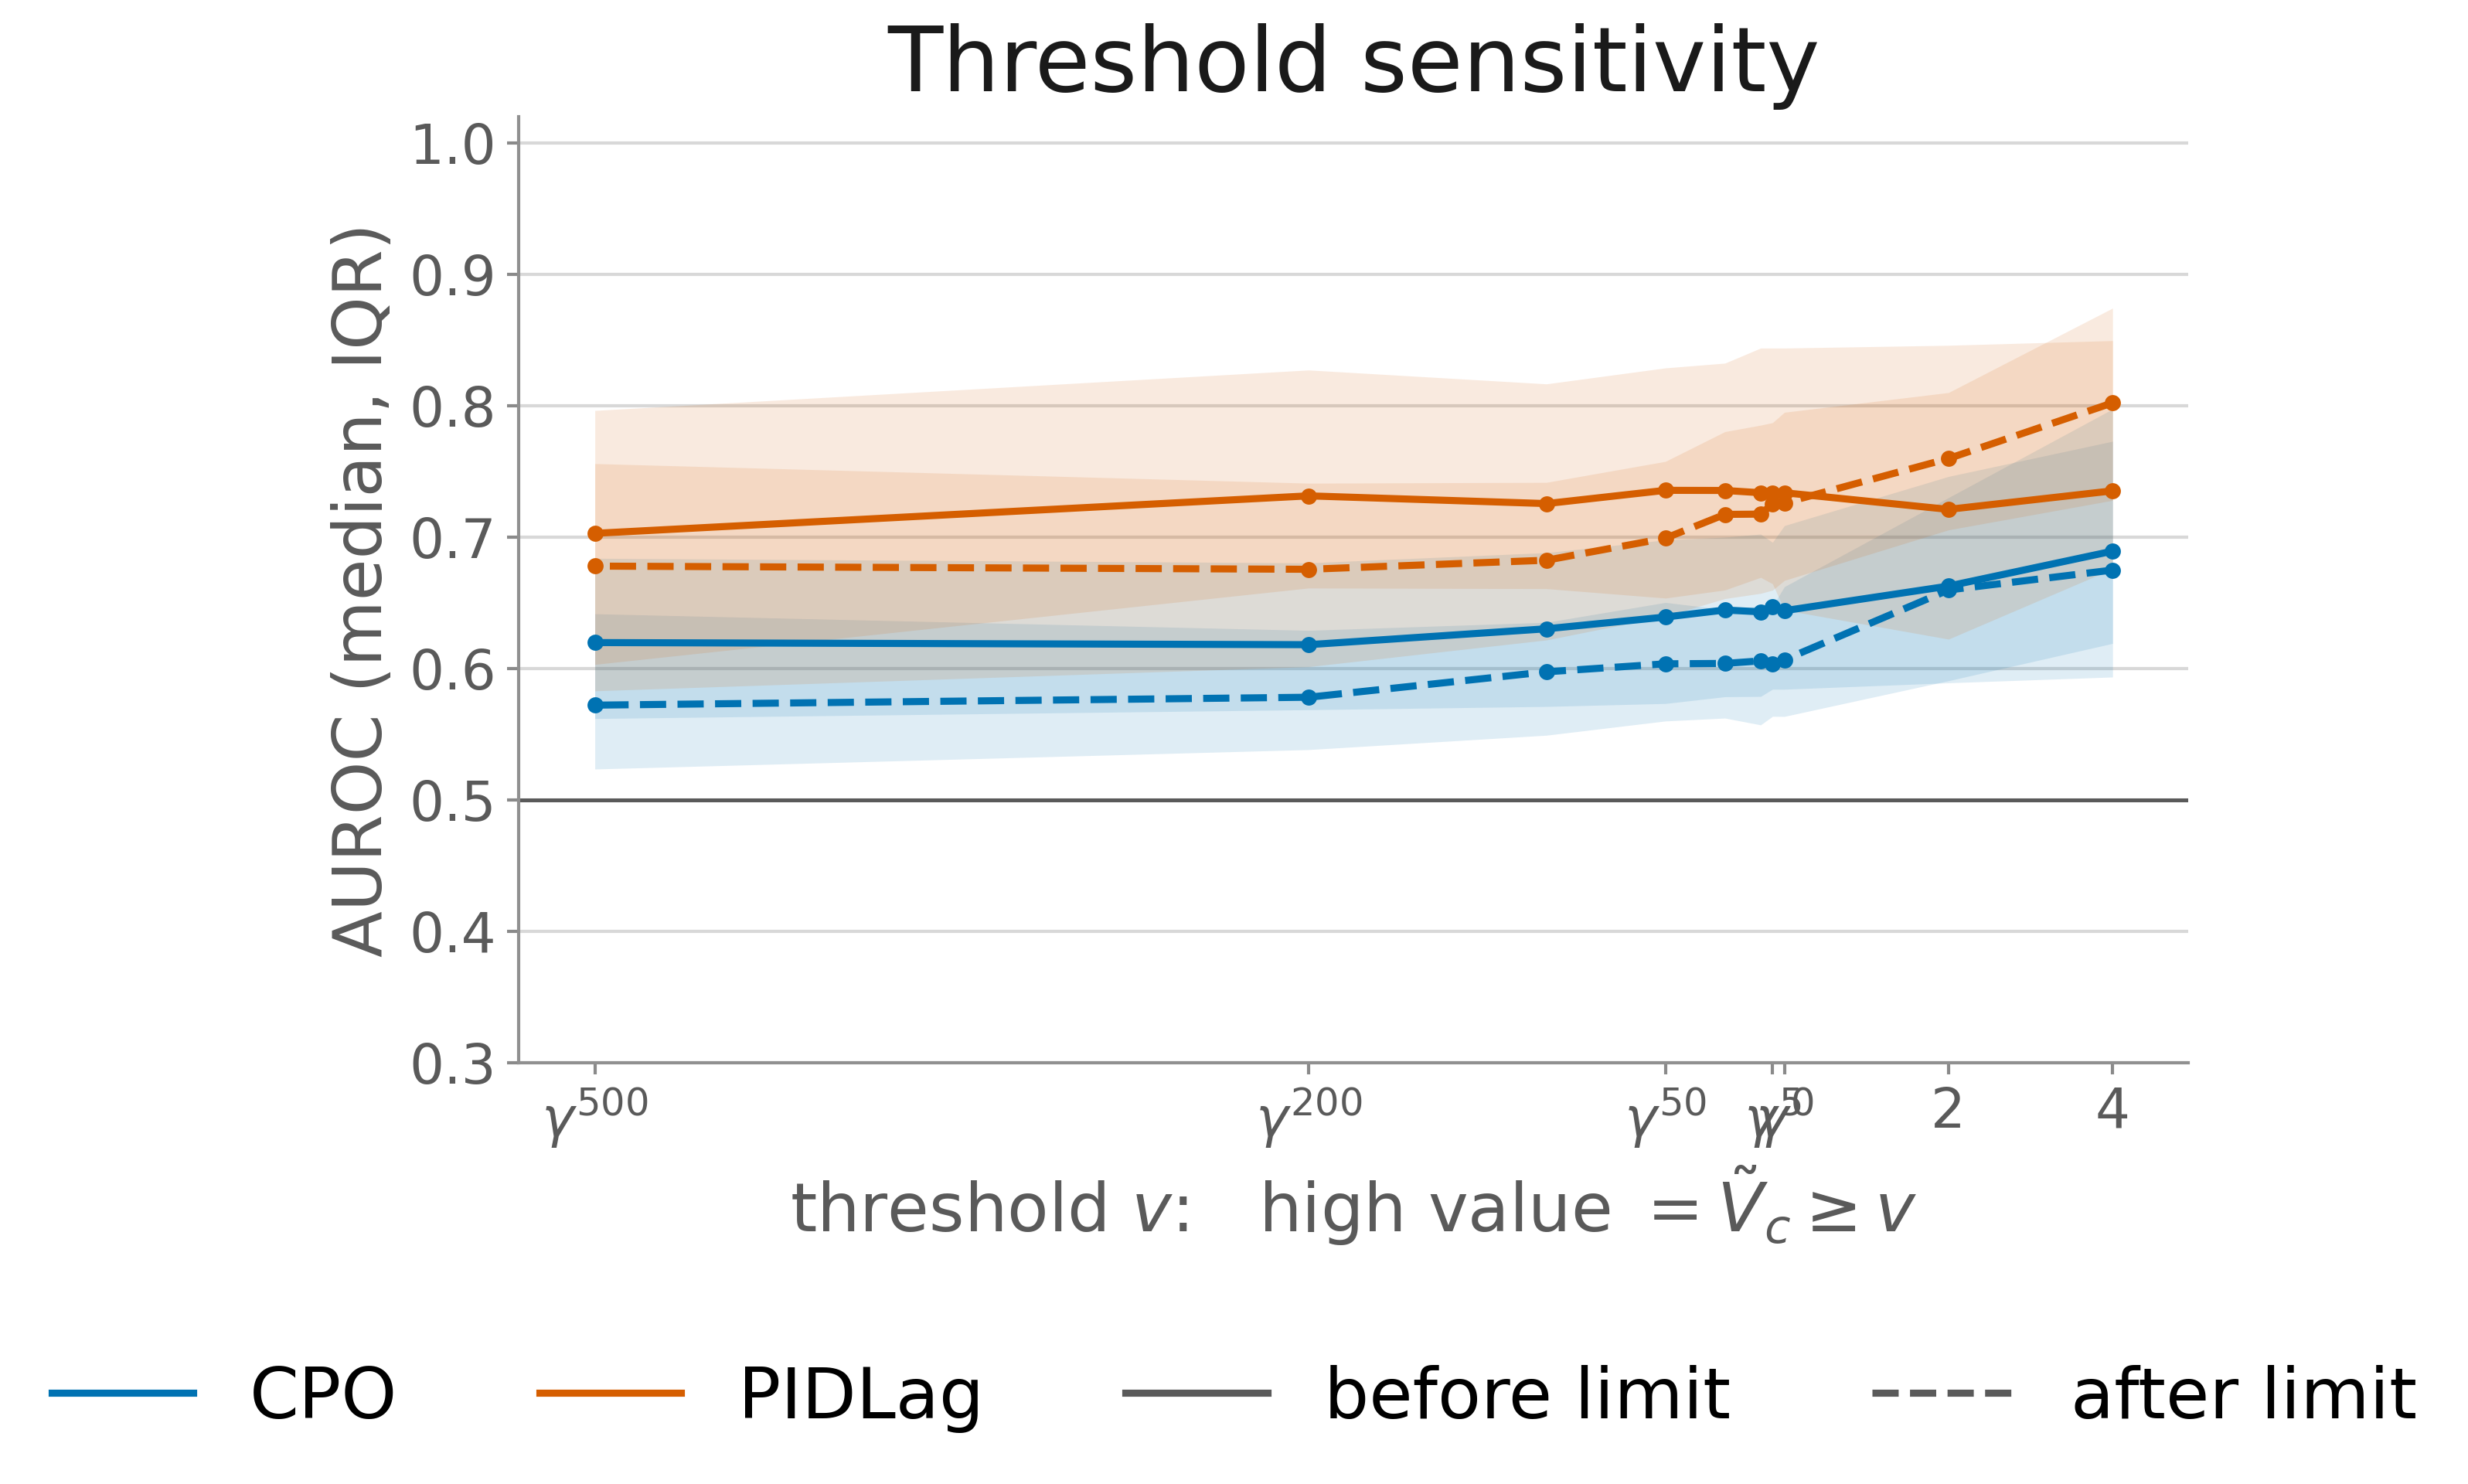

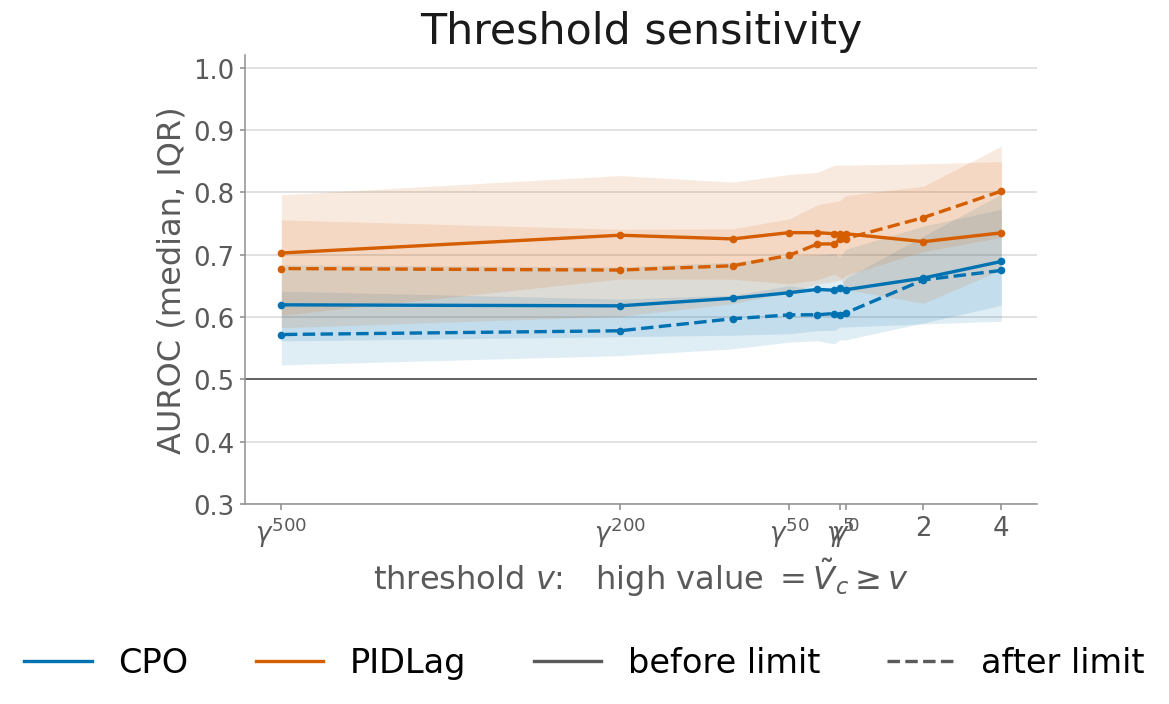

In [13]:
THRESH = {
    "values": [4.0, 2.0, 1.0] + [GAMMA ** t for t in (5, 10, 25, 50, 100, 200, 500)],
    "labels": ["4", "2", r"$\gamma^0$", r"$\gamma^5$", r"$\gamma^{10}$", r"$\gamma^{25}$",
               r"$\gamma^{50}$", r"$\gamma^{100}$", r"$\gamma^{200}$", r"$\gamma^{500}$"],
    "shown": [0, 1, 2, 3, 6, 8, 9],       # which ticks to label
    "ylim": (0.30, 1.02),
    "legend_in": 0.95,
}


def auroc_vs_threshold(d):
    """AUROC at each threshold, for every (seed, checkpoint)."""
    n_s, n_t = d["pred_c"].shape[:2]
    return np.array([[[auroc(d["pred_c"][s, t], d["G_c"][s, t].mean(-1) >= v)
                       for v in THRESH["values"]]
                      for t in range(n_t)] for s in range(n_s)])


def figure_threshold(series=None, title=None):
    """AUROC for the "high value" cut, swept over where that cut is drawn.

    `series` is a list of (data, colour, label), defaulting to the two algorithms at
    their selected configs.  Colour is the series, line style the training phase.
    """
    if series is None:
        series = [(DATA[algo], ALGO_COLOR[disp], disp) for algo, disp in ALGOS]
    fig, ax = make_axes(1, legend_in=THRESH["legend_in"], panel_w=STYLE["panel"]["w"] * 1.5)
    ax = ax[0]
    for d, col, _ in series:
        A = auroc_vs_threshold(d)
        for phase, ls in ((d["steps"] < d["x0"], "-"), (d["steps"] >= d["x0"], "--")):
            V = A[:, phase, :].reshape(-1, len(THRESH["values"]))
            if not len(V):
                continue
            ax.plot(THRESH["values"], np.nanmedian(V, 0), color=col, ls=ls,
                    lw=STYLE["line"]["width"], marker="o",
                    markersize=STYLE["line"]["marker"], markeredgewidth=0)
            ax.fill_between(THRESH["values"], np.nanpercentile(V, 25, 0),
                            np.nanpercentile(V, 75, 0), color=col,
                            alpha=STYLE["line"]["band_alpha"] * 0.7, lw=0)
    ax.axhline(0.5, color=STYLE["ink"]["rule"], lw=1.2)
    ax.set_xscale("log")
    ax.set_xticks([THRESH["values"][i] for i in THRESH["shown"]])
    ax.set_xticklabels([THRESH["labels"][i] for i in THRESH["shown"]])
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.set_ylim(*THRESH["ylim"])
    ax.set_xlabel(TEXT["threshold_x"])
    ax.set_ylabel(TEXT["threshold_y"])
    ax.set_title(title or TEXT["threshold_title"])

    legend_below(fig, [(line_key(col), lab) for _, col, lab in series]
                 + [(line_key(STYLE["ink"]["rule"], ls="-"), TEXT["threshold_before"]),
                    (line_key(STYLE["ink"]["rule"], ls="--"), TEXT["threshold_after"])],
                 ncol=4)
    thin_tick_labels(fig, ax)      # gamma^0 and gamma^5 are 5% apart on this log axis
    return fig


save(figure_threshold(), "fig2_threshold")
show("fig2_threshold", width=800)

### 7.1 Monte-Carlo vs GAE advantages, per algorithm

One figure per algorithm, comparing its best `plain` config against its best `gae` one.
`plain` is the Monte-Carlo advantage estimator, so the pair asks whether the cost critic's
ranking of states depends on how advantages are estimated at all.

Each variant is scored inside its own `adv` pool by `SELECT["criterion"]`, so this is
best-against-best rather than a matched pair — the winners may differ in `update_iters` and
`critic.lr` too, and the two algorithms need not pick the same cells as each other. The
cells actually chosen are printed below. Colour is the variant and line style the training
phase, exactly as in the figure above.

Section 4 caches only the one cell it selects per algorithm, so the first run here downloads
whatever else these pairs need.

In [ ]:
VARIANTS = {
    # one figure per algorithm, each at its own best config per estimator
    "algos": [algo for algo, _ in ALGOS],
    # (adv-estimation-method, label).  "plain" is the Monte-Carlo estimator.
    "compare": [("plain", "MC"), ("gae", "GAE")],
}


def variant_data(algo, adv):
    """`algo`'s best cell under one adv-estimation-method, probes fetched if missing."""
    cell = best_cells(raw, SELECT["criterion"], variant=adv)[0][algo]
    ok, detail = tree_status(algo, cell, raw)
    if not ok:
        print(f"    {adv:>5}: {cell} -- {detail}; downloading")
        download_tree(algo, cell, raw)
        ok, detail = tree_status(algo, cell, raw)
        if not ok:
            raise RuntimeError(f"{algo}/{adv}: {cell} still incomplete -- {detail}")
    print(f"    {adv:>5}: {cell} ({detail})")
    return load_algo(algo, cell, ts)


DISPLAY = dict(ALGOS)
variant_stems = []
for variant_algo in VARIANTS["algos"]:
    disp = DISPLAY[variant_algo]
    print(f"{disp}:")
    series = [(variant_data(variant_algo, adv), STYLE["variant"][adv], lab)
              for adv, lab in VARIANTS["compare"]]
    stem = f"fig2_threshold_{disp.lower()}_variants"
    save(figure_threshold(series,
                          TEXT["threshold_variants_title"].format(algo=disp)), stem)
    variant_stems.append(stem)
show(*variant_stems, width=800)

## 8. Value-group composition

How the probe set itself shifts between value groups as the policy changes — context for
reading the by-group error panel, since the groups are not a fixed population.

In [ ]:
GROUPS_FIG = {"legend_in": 0.95, "title_in": 0.55, "ylim": (0, 1)}


def figure_groups():
    fig, ax = make_axes(len(ALGOS), legend_in=GROUPS_FIG["legend_in"],
                        title_in=GROUPS_FIG["title_in"])
    for a, (algo, disp) in zip(ax, ALGOS):
        d = DATA[algo]
        S = np.array([[[m.mean() for m in value_groups(d["G_c"][s, t].mean(-1))]
                       for t in range(len(d["steps"]))] for s in range(len(d["seeds"]))])
        a.stackplot(d["steps"], S.mean(0).T, colors=STYLE["groups"], edgecolor="none")
        rule_v(a, d["x0"])
        log_steps(a, d["steps"][0], X_LAST)
        a.set_ylim(*GROUPS_FIG["ylim"])
        a.set_title(disp)
        a.grid(False)
    ax[0].set_ylabel(TEXT["groups_y"])
    legend_below(fig, [(Patch(facecolor=STYLE["groups"][i], edgecolor="none"),
                        TEXT["group_defs"][i]) for i in range(3)], ncol=3)
    suptitle(fig, TEXT["groups_title"])
    return fig


save(figure_groups(), "fig2_groups")
show("fig2_groups", width=900)

## 9. Reliability of the reference

$\bar G$ averages only K=10 rollouts, so it is a noisy stand-in for $V^\pi$ and even a
perfect critic cannot correlate with it at 1. The attainable ceiling is

$$\rho_{\max}(K)=\sqrt{\mathrm{Var}[V]\,/\,(\mathrm{Var}[V]+\mathbb{E}[\sigma^2]/K)}$$

estimated by ANOVA (dashed) and cross-checked by a split-half estimate that assumes only
independent rollouts (dotted). If the two agree and both sit well above the observed
correlation, the Figure 1 correlations are not an artefact of reference noise.

In [ ]:
REL = {"ylim": (0.0, 1.05), "legend_in": 1.05, "n_rep": 200}


def figure_reliability():
    fig, ax = make_axes(4, legend_in=REL["legend_in"])
    L, ink = STYLE["line"], STYLE["ink"]

    for j, head in enumerate(("r", "c")):
        for algo, disp in ALGOS:
            d, col = DATA[algo], ALGO_COLOR[disp]
            obs = map_checkpoints(d, head, rho_obs)
            rmax = map_checkpoints(d, head, lambda p, G: rho_max(G))
            rsplit = map_checkpoints(d, head,
                                     lambda p, G: splithalf_r(G, n_rep=REL["n_rep"]))

            band(ax[j], d["steps"], obs, col, marker="o")
            ax[j].plot(d["steps"], np.nanmean(rmax, 0), color=col,
                       lw=L["ceiling_width"], ls="--", zorder=4)
            ax[j].plot(d["steps"], [rho_max_from_split(r) for r in np.nanmean(rsplit, 0)],
                       color=col, lw=L["ceiling_width"], ls=L["ceiling_dash"], zorder=4)

            band(ax[2 + j], d["steps"], rsplit, col, marker="o")
            ax[2 + j].plot(d["steps"], np.nanmean(rmax, 0) ** 2, color=col,
                           lw=L["ceiling_width"], ls="--", zorder=4)

    for a, title in zip(ax, TEXT["rel_titles"]):
        a.set_title(title)
        a.set_ylim(*REL["ylim"])
        log_steps(a, X_FIRST, X_LAST)

    # The algorithms are named in the legend, not at the curve ends: end-labels widen
    # the panel they sit in, and that panel alone, which both crowds its x ticks and
    # leaves it on a different x range from the three beside it.
    legend_below(fig, [(line_key(ALGO_COLOR[disp]), disp) for _, disp in ALGOS]
                      + [(line_key(ink["rule"]), TEXT["rel_observed"]),
                         (line_key(ink["rule"], lw=L["ceiling_width"], ls="--"),
                          TEXT["rel_anova"]),
                         (line_key(ink["rule"], lw=L["ceiling_width"],
                                   ls=L["ceiling_dash"]), TEXT["rel_split"])], ncol=5)
    return fig


save(figure_reliability(), "reliability")
show("reliability")

## 10. Rollout budget

How many rollouts per probe the reference actually needs. This sweep logs K=10, so the
empirical curves stop there (split halves at K$\leq$5); the ANOVA $\rho_{\max}(K)$ is a
fitted model, so it extrapolates past the data — that region is shaded.

In [ ]:
BUDGET = {
    "algo": "CPO", "seed_index": 0,
    "ks": [1, 2, 3, 5, 10],          # empirical, needs K rollouts
    "ks_split": [1, 2, 3, 5],        # split-half, needs 2K
    "k_model": np.arange(1, 41),     # ANOVA curve, extrapolated
    "draws": 200, "ylim_rho": (0.5, 1.005), "legend_in": 1.0, "title_in": 0.55,
}


def budget_curves(G, rng):
    """Per checkpoint: relative error vs the full estimate, rho_max(K), split-half corr."""
    n, K = G.shape
    Gb = np.broadcast_to(G, (BUDGET["draws"], n, K))
    sigma2 = G.var(1, ddof=1).mean()
    lam = max(G.mean(1).var(ddof=1) - sigma2 / K, 0.0) / sigma2 if sigma2 > 0 else 0.0
    out = {"rho": np.sqrt(BUDGET["k_model"] * lam / (BUDGET["k_model"] * lam + 1)),
           "relerr": {}, "split": {}}
    gfull = G.mean(1)
    for k in BUDGET["ks"]:
        if k == K:
            out["relerr"][k] = 0.0
            continue
        idx = np.argsort(rng.random((BUDGET["draws"], n, K)), 2)[:, :, :k]
        M = np.take_along_axis(Gb, idx, 2).mean(2)
        out["relerr"][k] = float(np.median(np.sqrt(((M - gfull) ** 2).mean(1)))
                                 / gfull.std(ddof=1))
    for k in BUDGET["ks_split"]:
        idx = np.argsort(rng.random((BUDGET["draws"], n, K)), 2)
        A = np.take_along_axis(Gb, idx[:, :, :k], 2).mean(2)
        B = np.take_along_axis(Gb, idx[:, :, k:2 * k], 2).mean(2)
        Ac, Bc = A - A.mean(1, keepdims=True), B - B.mean(1, keepdims=True)
        den = np.sqrt((Ac ** 2).sum(1) * (Bc ** 2).sum(1))
        out["split"][k] = float(np.nanmean((Ac * Bc).sum(1)[den > 0] / den[den > 0]))
    return out


def figure_budget():
    d = DATA[BUDGET["algo"]]
    s = BUDGET["seed_index"]
    rng = np.random.default_rng(0)
    heads = [("r", TEXT["reward"]), ("c", TEXT["cost"])]
    Cv = {h: [budget_curves(d[f"G_{h}"][s, t], rng) for t in range(len(d["steps"]))]
          for h, _ in heads}

    fig, ax = make_axes(4, legend_in=BUDGET["legend_in"],
                        title_in=BUDGET["title_in"])
    ks, ks_split = BUDGET["ks"], BUDGET["ks_split"]
    L = STYLE["line"]

    for h, _ in heads:
        col = STYLE["heads"][h]
        E = np.array([[c["relerr"][k] for k in ks] for c in Cv[h]])
        ax[0].plot(ks, np.median(E, 0), color=col, lw=L["width"], marker="o",
                   markersize=L["marker"], markeredgewidth=0)
        ax[0].fill_between(ks, E.min(0), E.max(0), color=col, alpha=L["band_alpha"], lw=0)

        R = np.array([c["rho"] for c in Cv[h]])
        ax[1].plot(BUDGET["k_model"], np.median(R, 0), color=col, lw=L["width"])
        ax[1].fill_between(BUDGET["k_model"], R.min(0), R.max(0), color=col,
                           alpha=L["band_alpha"], lw=0)

        kb = max(ks_split)
        ax[2].plot(d["steps"], [c["split"][kb] for c in Cv[h]], color=col, lw=L["width"],
                   marker="o", markersize=L["marker"], markeredgewidth=0)

        S = np.array([[c["split"][k] for k in ks_split] for c in Cv[h]])
        ax[3].plot(ks_split, np.median(S, 0), color=col, lw=L["width"], marker="o",
                   markersize=L["marker"], markeredgewidth=0)
        ax[3].fill_between(ks_split, S.min(0), S.max(0), color=col,
                           alpha=L["band_alpha"], lw=0)
        Pm = np.array([c["rho"][np.array(ks_split) - 1] ** 2 for c in Cv[h]])
        ax[3].plot(ks_split, np.median(Pm, 0), color=col, lw=L["ceiling_width"],
                   ls=L["ceiling_dash"])

    ax[0].set_ylim(0, None)
    ax[0].set_ylabel(TEXT["budget_y_err"])
    ax[1].set_ylim(*BUDGET["ylim_rho"])
    ax[1].set_ylabel(TEXT["budget_y_rho"])
    ax[1].axvspan(max(ks), BUDGET["k_model"][-1], color="#eeeeee", zorder=0)
    ax[1].text(max(ks) * 1.25, BUDGET["ylim_rho"][0] + 0.06, TEXT["budget_extrap"],
               fontsize=STYLE["font"]["note"], color=STYLE["ink"]["label"], style="italic")
    ax[2].set_ylim(*BUDGET["ylim_rho"])
    ax[2].set_ylabel(TEXT["budget_y_split"])
    log_steps(ax[2], d["steps"][0], X_LAST)
    ax[3].set_ylim(*BUDGET["ylim_rho"])
    ax[3].set_ylabel(TEXT["budget_y_split"])

    for a, ticks, xlab in ((ax[0], ks, TEXT["budget_x_k"]),
                           (ax[1], [1, 2, 5, 10, 20, 40], TEXT["budget_x_k"]),
                           (ax[3], ks_split, TEXT["budget_x_half"])):
        a.axvline(max(ks), color=STYLE["ink"]["rule"], ls="--", lw=1.2)
        a.set_xscale("log")
        a.set_xticks(ticks)
        a.set_xticklabels([str(k) for k in ticks])
        a.xaxis.set_minor_locator(mticker.NullLocator())
        a.set_xlabel(xlab)
    for a, title in zip(ax, TEXT["budget_titles"]):
        a.set_title(title)

    legend_below(fig, [(line_key(STYLE["heads"][h]), lab) for h, lab in heads]
                 + [(line_key(STYLE["ink"]["rule"], lw=L["ceiling_width"],
                              ls=L["ceiling_dash"]), TEXT["budget_pred"]),
                    (line_key(STYLE["ink"]["rule"], ls="--", lw=1.2),
                     f"K = {max(ks)} (all rollouts)")], ncol=4)
    suptitle(fig, f"{BUDGET['algo']} ({d['cell']}) seed {d['seeds'][s]}")
    return fig


save(figure_budget(), "rollout_budget")
show("rollout_budget")

## 11. Output

In [ ]:
for p in sorted(FIG_DIR.iterdir()):
    print(f"{p.stat().st_size / 1e3:8.1f} kB  {p.name}")